# Regresión logística y Entropía



En el presente jupyter notebook se pretende realizar una regresión logística que permita predecir qué jugadores de la NBA van a tener una carrera deportiva de 5 o más años a partir de ciertas variables. Para ello, después de haber realizado las recodificaciones pertenecientes del dataset, se realizará un análisis de Correlaciones donde se observarán sobretodo las variables que tienen relación con la variable target, es decir, la que pretende predecir el modelo. Seguidamente se hará un Análisis de Componentes Principales con la intención de reducir la dimensionalidad de las variables en nuevas variables que sean independientes entre ellas (pues no interesa que haya colinealidad) y ver las variables que sean realmente importantes para explicar la variable target. Después se aplicarán diversos algoritmos que permitirán cuantificar la información mútua y así ver la relevancia de las variables y finalmente, habiendo elegido las variables más adecuadas mediante todos los procedimientos mencionados, se podrá realizar un modelo de regresión logística. El objetivo de este análisis es maximizar la clasificación de instancias de aquellos jugadores cuya trayectoria es más larga (de 5 o más años) respecto a la variable target que viene predefinida en el dataset.

## 1. Visualización, limpieza y comprensión del dataset
El dataset del que parte el estudio tiene las siguientes variables:

| **Nombre** | **Descripción** |
|-------|-----------|
| Name | Nombre del jugador |
| GP | Partidos jugados |
| MIN | Minutos jugados |
| PTS | Puntos por partido |
| FGM | Tiros de campo |
| FGA | Intentos de tiros de campo |
| FG% | Acierto de puntos (%) |
| X3P Made | Triples anotados |
| X3PA | Intento de triples |
| X3P. | Intento de triples (%) |
| FTM | Tiros libres realizados |
| FTA | Tiros libres intentados |
| FT% | Tiros libres (%) |
| OREB | Rebotes ofensivos |
| DREB | Rebotes defensivos |
| REB | Rebotes |
| AST | Asistencias |
| STL | Robatorios |
| BLK | Bloqueos |
| TOV | Cesión del balón |
| TARGET_5yrs | Variable target |


La última variable (la variable target) se presenta como de tipo booleano; 0 para aquellos jugadores cuya carrera va a durar menos de 5 años y 1 para los jugadores con una carrera más larga de 5 años (o 5 años). Es la variable que se intenta predecir.

In [1]:
install.packages("corrplot")
install.packages("FSelectorRcpp")
install.packages("caret")

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

also installing the dependencies ‘pkgbuild’, ‘rprojroot’, ‘diffobj’, ‘brio’, ‘callr’, ‘desc’, ‘pkgload’, ‘praise’, ‘processx’, ‘ps’, ‘waldo’, ‘BH’, ‘RcppArmadillo’, ‘testthat’


Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [2]:
### Librerías
library(dplyr)
library(corrplot)
library(FSelectorRcpp)
library(caret)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded

Loading required package: ggplot2

Loading required package: lattice



In [3]:
### Carga del dataset
nba <- read.csv2("../data/nba_logreg.csv", sep = ",", header = TRUE)
### Primera visualización del dataset: dim, head y summary
dim(nba)
head(nba, 5)

[1] 1340   21

,Name,GP,MIN,PTS,FGM,FGA,FG.,X3P.Made,X3PA,X3P.,⋯,FTA,FT.,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,⋯,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
2,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,⋯,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
3,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,⋯,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0
4,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,⋯,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1.0
5,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,⋯,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1.0


In [4]:
summary(nba)

     Name                 GP            MIN                PTS           
 Length:1340        Min.   :11.00   Length:1340        Length:1340       
 Class :character   1st Qu.:47.00   Class :character   Class :character  
 Mode  :character   Median :63.00   Mode  :character   Mode  :character  
                    Mean   :60.41                                        
                    3rd Qu.:77.00                                        
                    Max.   :82.00                                        
     FGM                FGA                FG.              X3P.Made        
 Length:1340        Length:1340        Length:1340        Length:1340       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                    

En un primer lugar tenemos una base de datos con 1340 registros y 21 variables. Se ha comprobado como en el dataset inicial no hay valores perdidos. A través del *Head()* y del *Summary()* se puede ver el tipo asignado a las diferentes variables del dataset. Aparecen todas las variables como de tipo carácter pero realmente son numéricas (excepto la variable NAME que representa el nombre del jugador y que está bien definida como carácter). Así pues, se les asigna el tipo correcto y se vuelve a presentar el *Summary()* resultante.

In [5]:
nba$MIN <- as.numeric(nba$MIN)
nba$PTS <- as.numeric(nba$PTS)
nba$FGM <- as.numeric(nba$FGM)
nba$FGA <- as.numeric(nba$FGA)
nba$FG. <- as.numeric(nba$FG.)
nba$X3P.Made <- as.numeric(nba$X3P.Made)
nba$X3PA <- as.numeric(nba$X3PA)
nba$X3P. <- as.numeric(nba$X3P.)
nba$FTM <- as.numeric(nba$FTM)
nba$FTA <- as.numeric(nba$FTA)
nba$FT. <- as.numeric(nba$FT.)
nba$OREB <- as.numeric(nba$OREB)
nba$DREB <- as.numeric(nba$DREB)
nba$REB <- as.numeric(nba$REB)
nba$AST <- as.numeric(nba$AST)
nba$STL <- as.numeric(nba$STL)
nba$BLK <- as.numeric(nba$BLK)
nba$TOV <- as.numeric(nba$TOV)
nba$TARGET_5Yrs <- as.numeric(nba$TARGET_5Yrs)

In [6]:
summary(nba)

     Name                 GP             MIN             PTS        
 Length:1340        Min.   :11.00   Min.   : 3.10   Min.   : 0.700  
 Class :character   1st Qu.:47.00   1st Qu.:10.88   1st Qu.: 3.700  
 Mode  :character   Median :63.00   Median :16.10   Median : 5.550  
                    Mean   :60.41   Mean   :17.62   Mean   : 6.801  
                    3rd Qu.:77.00   3rd Qu.:22.90   3rd Qu.: 8.800  
                    Max.   :82.00   Max.   :40.90   Max.   :28.200  
                                                                    
      FGM              FGA              FG.           X3P.Made     
 Min.   : 0.300   Min.   : 0.800   Min.   :23.80   Min.   :0.0000  
 1st Qu.: 1.400   1st Qu.: 3.300   1st Qu.:40.20   1st Qu.:0.0000  
 Median : 2.100   Median : 4.800   Median :44.10   Median :0.1000  
 Mean   : 2.629   Mean   : 5.885   Mean   :44.17   Mean   :0.2476  
 3rd Qu.: 3.400   3rd Qu.: 7.500   3rd Qu.:47.90   3rd Qu.:0.4000  
 Max.   :10.200   Max.   :19.800   Max. 

In [7]:
# Retiramos los valores NA en X3P.
nba <- nba %>% filter(!is.na(X3P.))
summary(nba)

     Name                 GP            MIN             PTS       
 Length:1329        Min.   :11.0   Min.   : 3.10   Min.   : 0.70  
 Class :character   1st Qu.:47.0   1st Qu.:10.80   1st Qu.: 3.70  
 Mode  :character   Median :63.0   Median :16.10   Median : 5.60  
                    Mean   :60.4   Mean   :17.65   Mean   : 6.82  
                    3rd Qu.:77.0   3rd Qu.:22.90   3rd Qu.: 8.80  
                    Max.   :82.0   Max.   :40.90   Max.   :28.20  
      FGM              FGA              FG.           X3P.Made     
 Min.   : 0.300   Min.   : 0.800   Min.   :23.80   Min.   :0.0000  
 1st Qu.: 1.400   1st Qu.: 3.300   1st Qu.:40.20   1st Qu.:0.0000  
 Median : 2.100   Median : 4.800   Median :43.90   Median :0.1000  
 Mean   : 2.635   Mean   : 5.902   Mean   :44.12   Mean   :0.2497  
 3rd Qu.: 3.400   3rd Qu.: 7.500   3rd Qu.:47.80   3rd Qu.:0.4000  
 Max.   :10.200   Max.   :19.800   Max.   :73.70   Max.   :2.3000  
      X3PA             X3P.             FTM            

In [8]:
### Balance de las clases de la variable target
print("Instancias de jugadores con una carrera mayor o igual a 5 años:")
sum(nba$TARGET_5Yrs)

print("Numero total de instancias:")
nrow(nba)

print("Proporcion de jugadores de carrera mayor o igual a 5 años sobre el total:")
round(sum(nba$TARGET_5Yrs) / nrow(nba),4) * 100

[1] "Instancias de jugadores con una carrera mayor o igual a 5 años:"


[1] 826

[1] "Numero total de instancias:"


[1] 1329

[1] "Proporcion de jugadores de carrera mayor o igual a 5 años sobre el total:"


[1] 62.15

In [9]:
#Generamos datasets filtrando por la clase
nba_1 <- nba[nba$TARGET_5Yrs == 1,]
nba_0 <- nba[nba$TARGET_5Yrs == 0,]

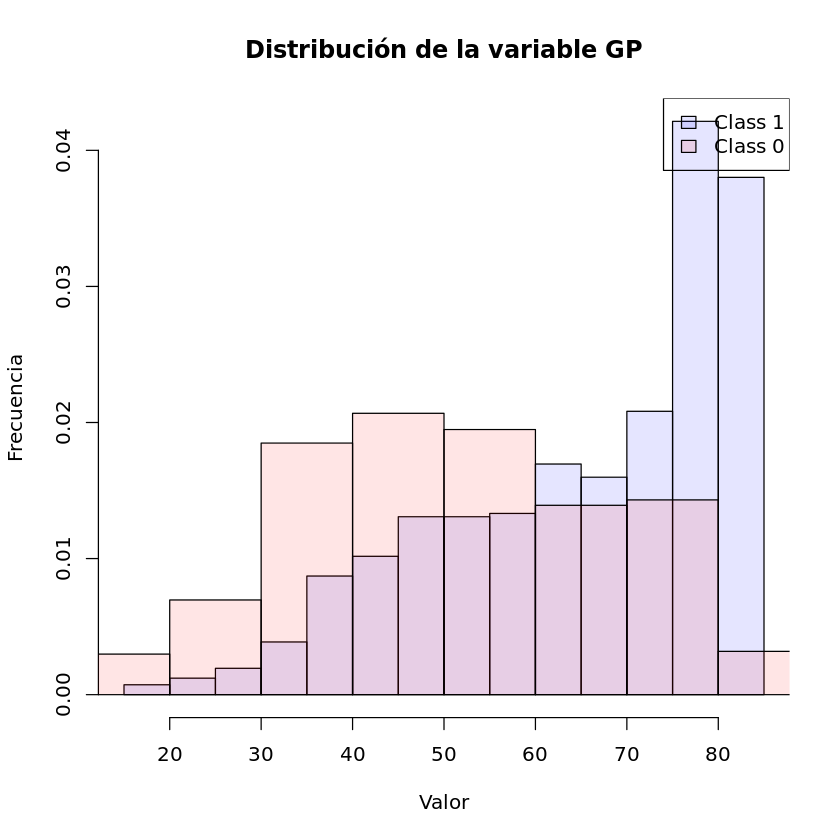

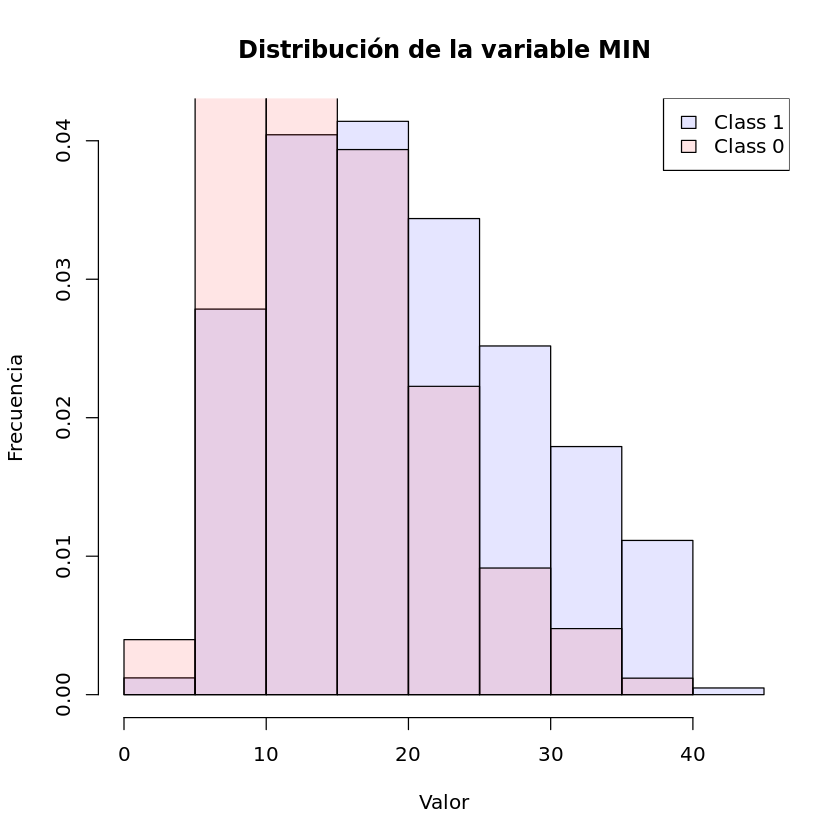

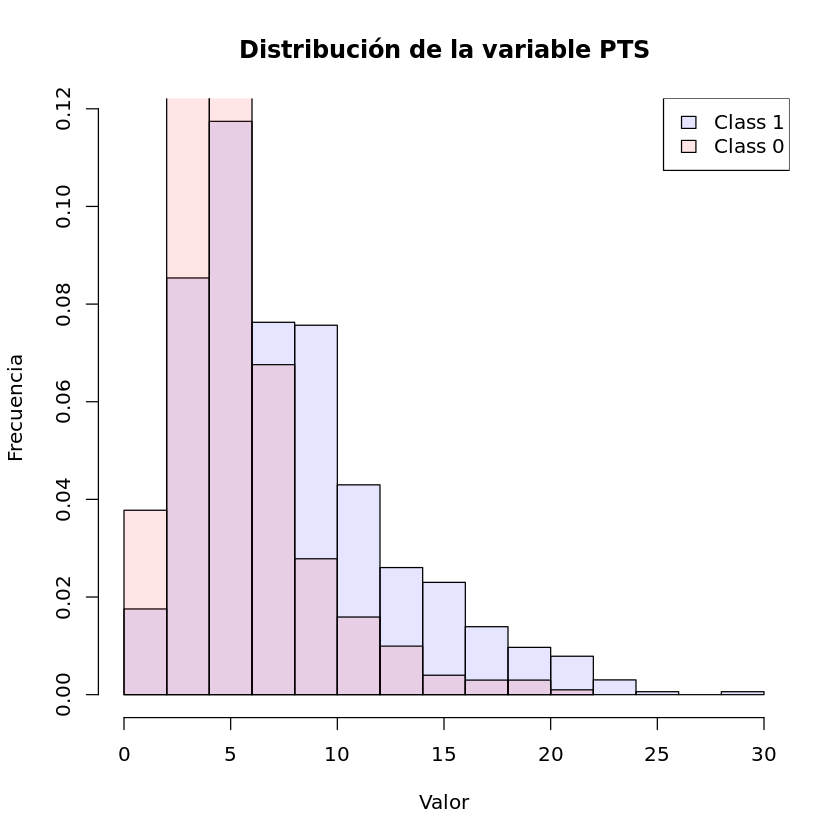

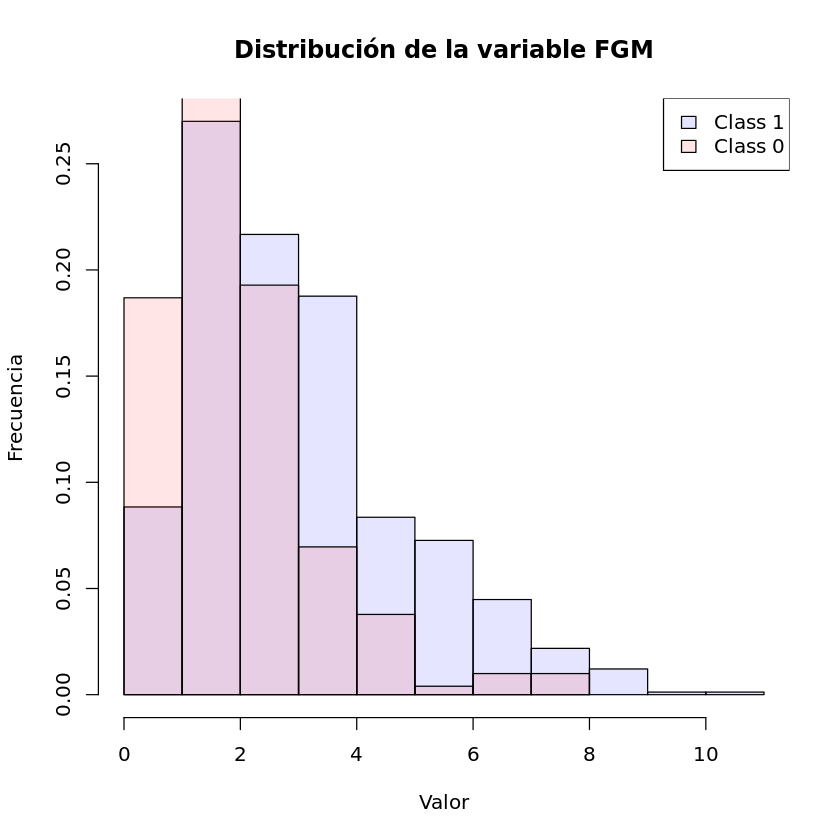

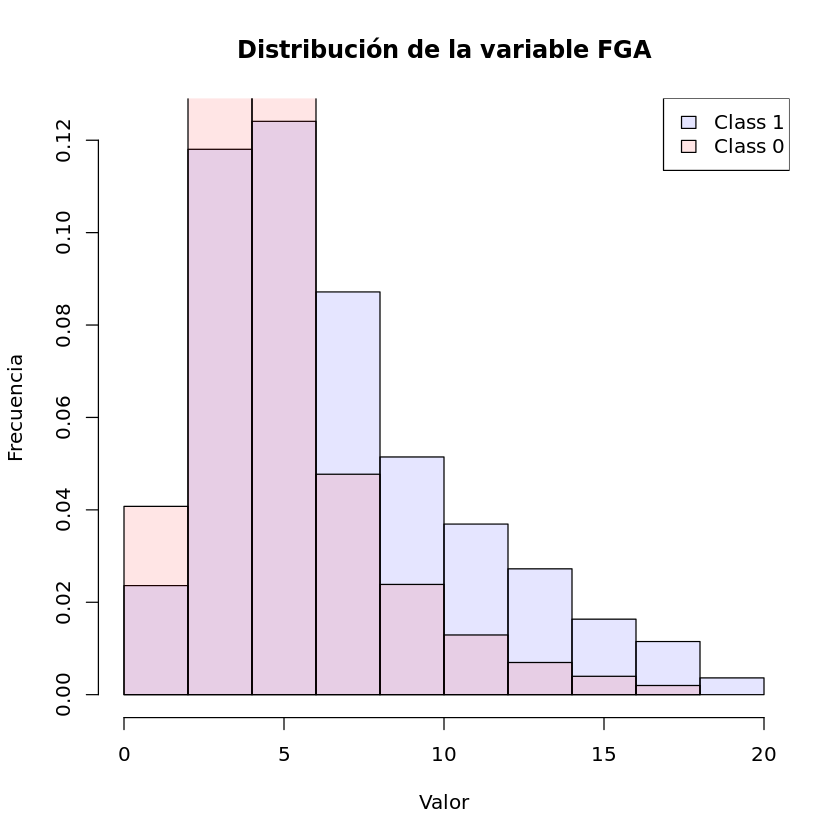

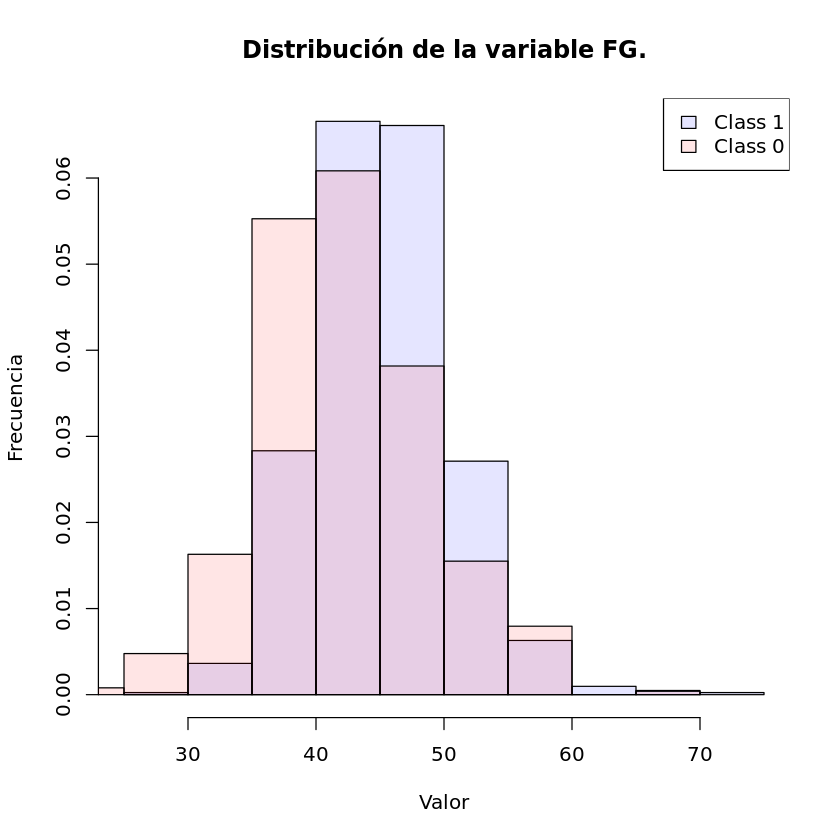

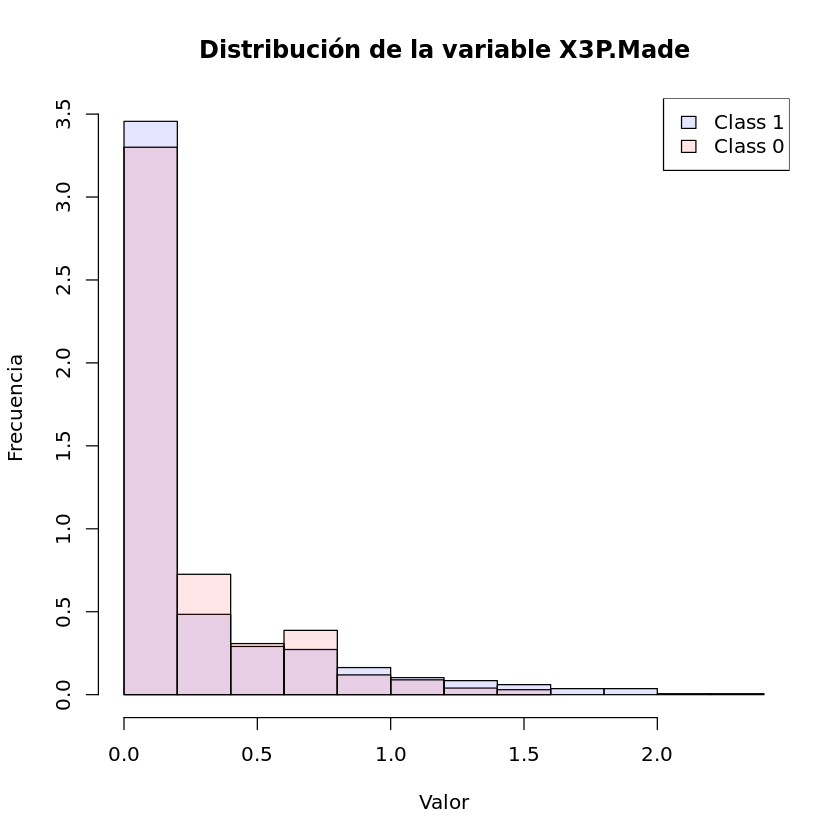

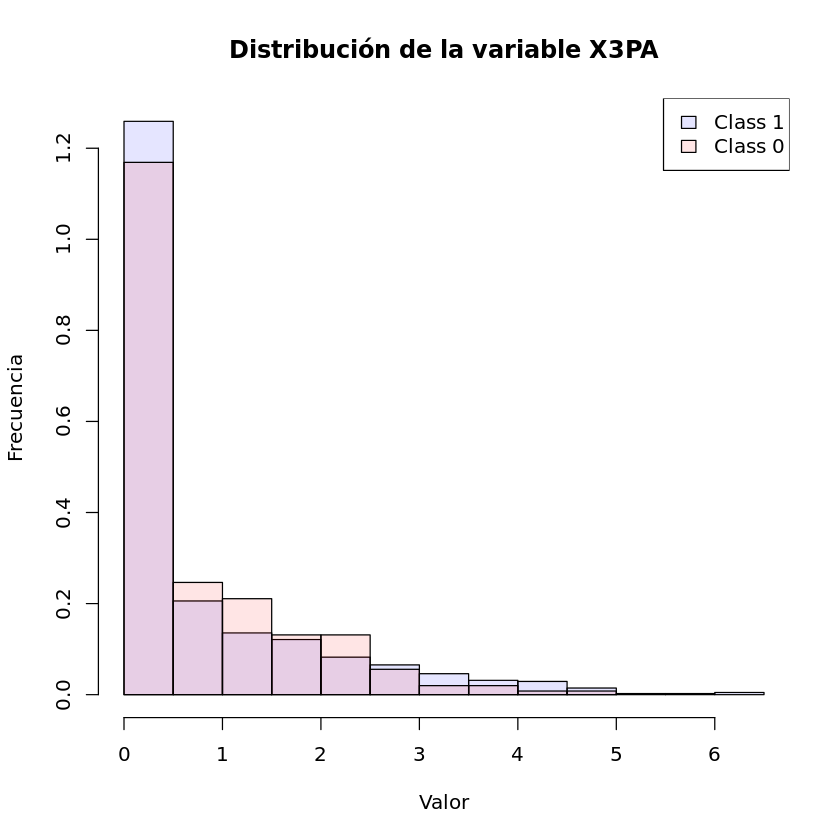

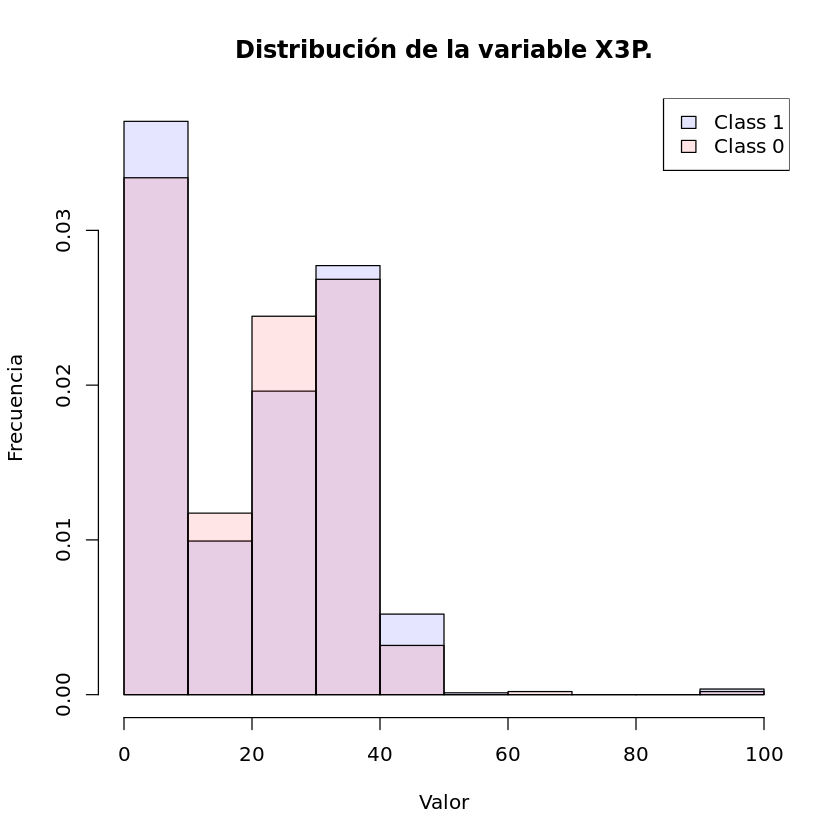

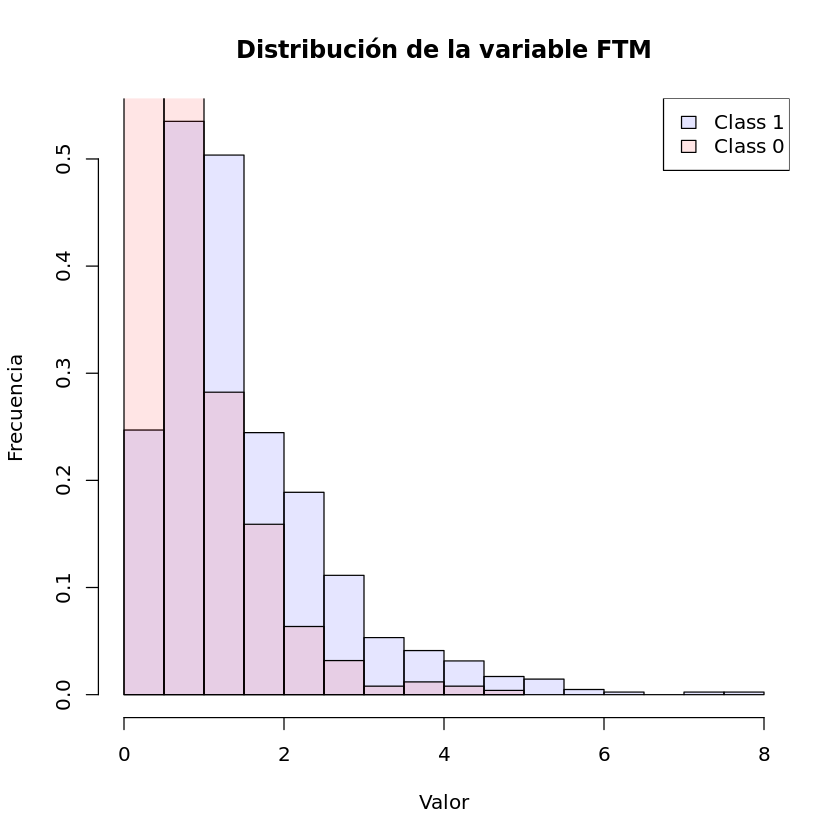

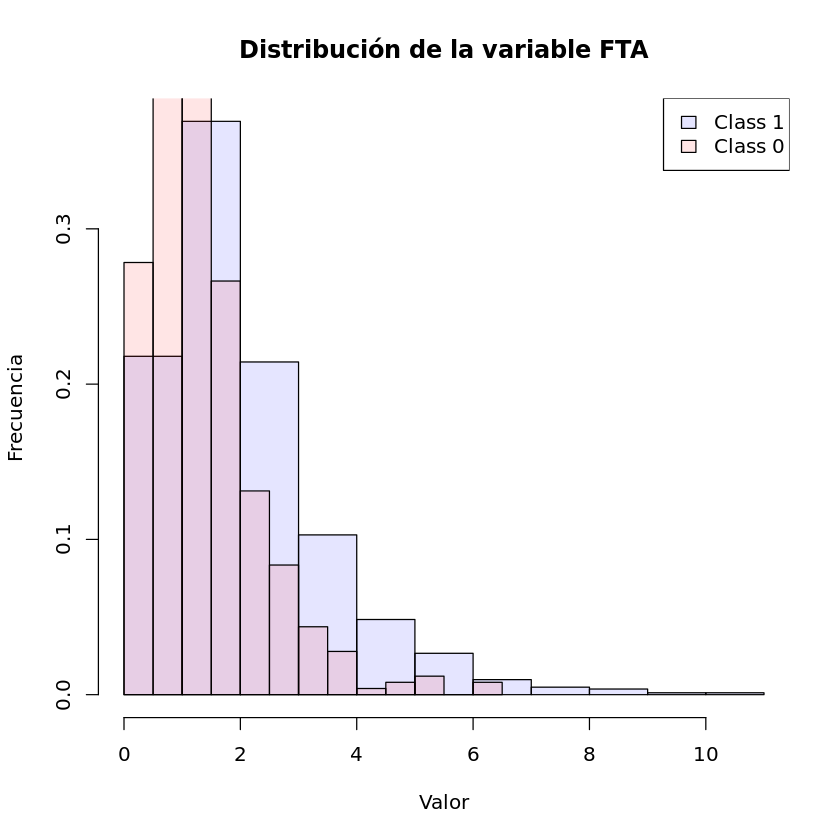

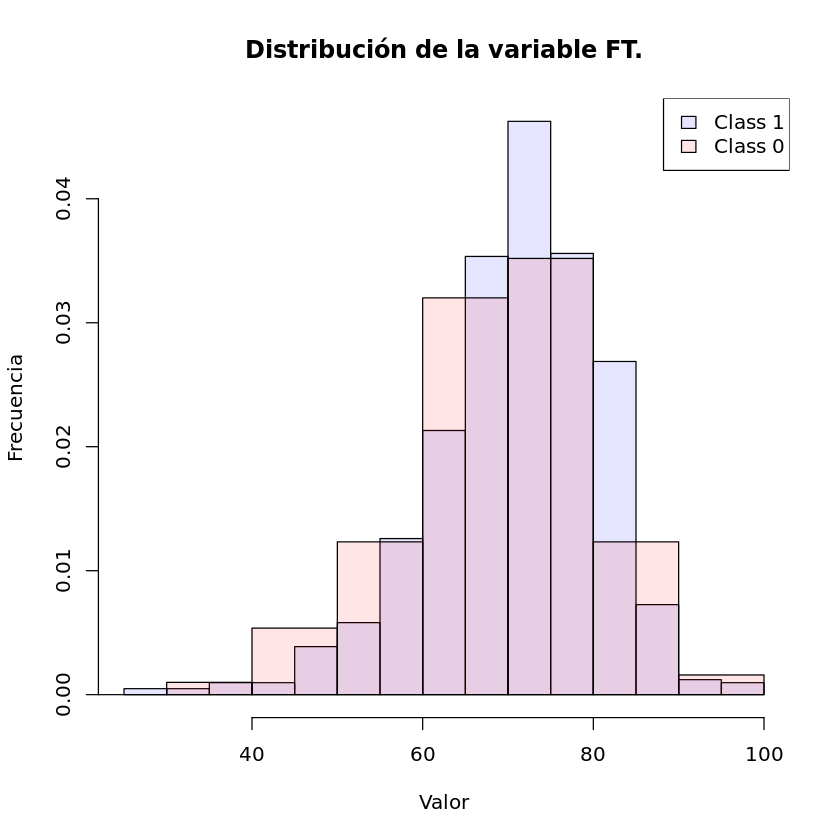

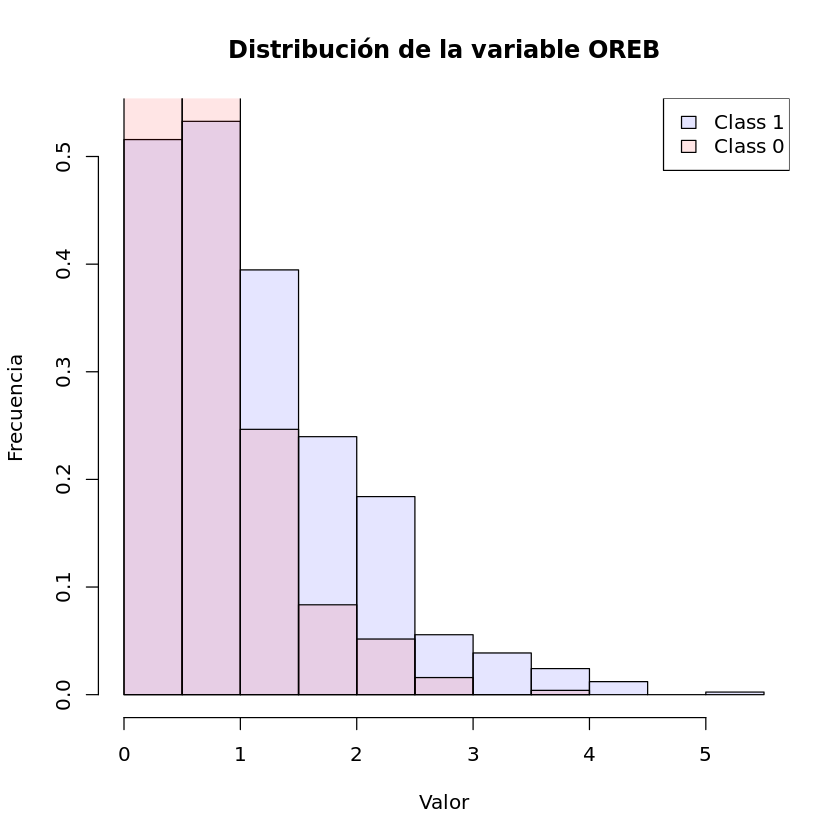

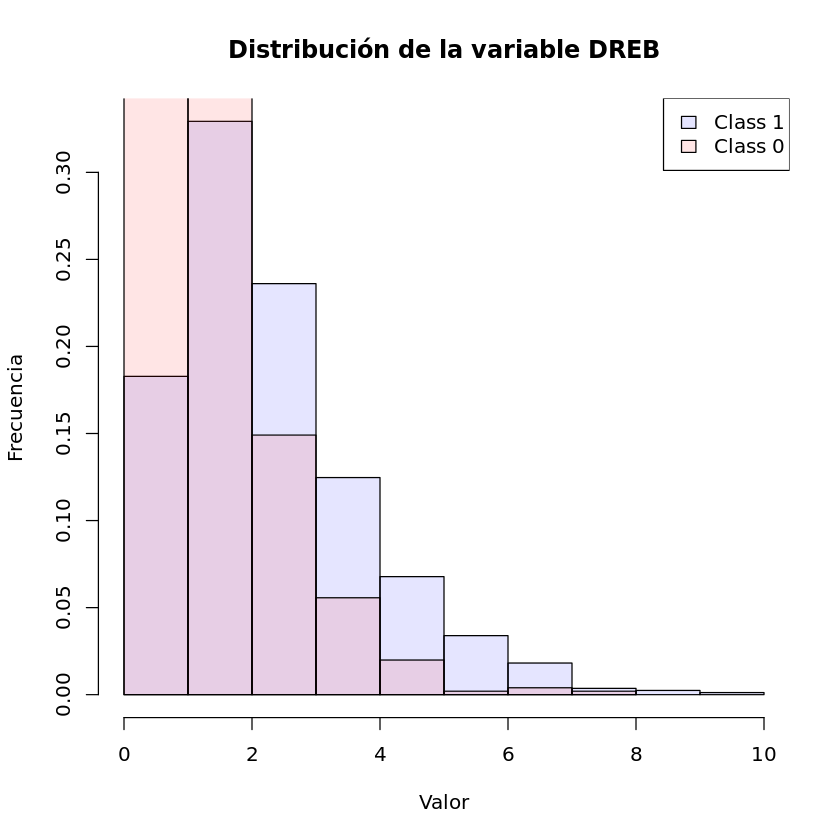

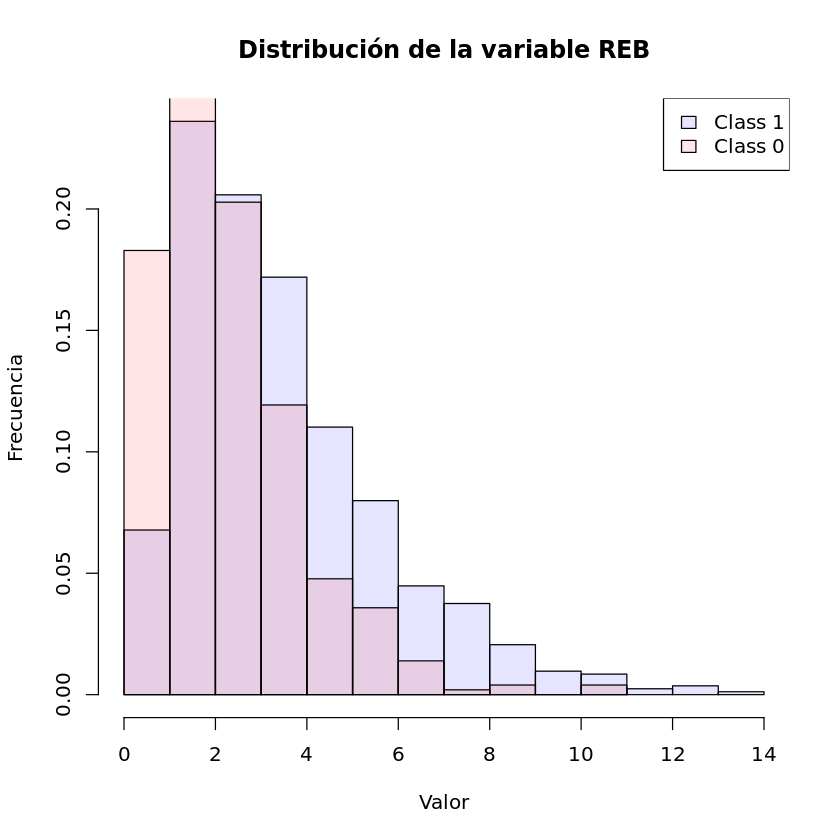

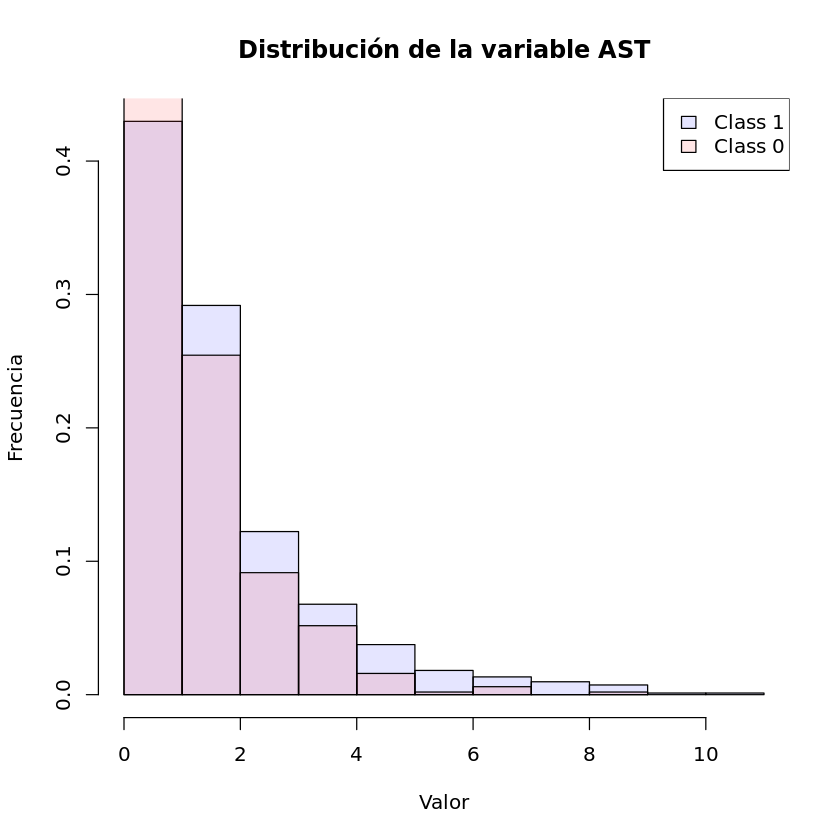

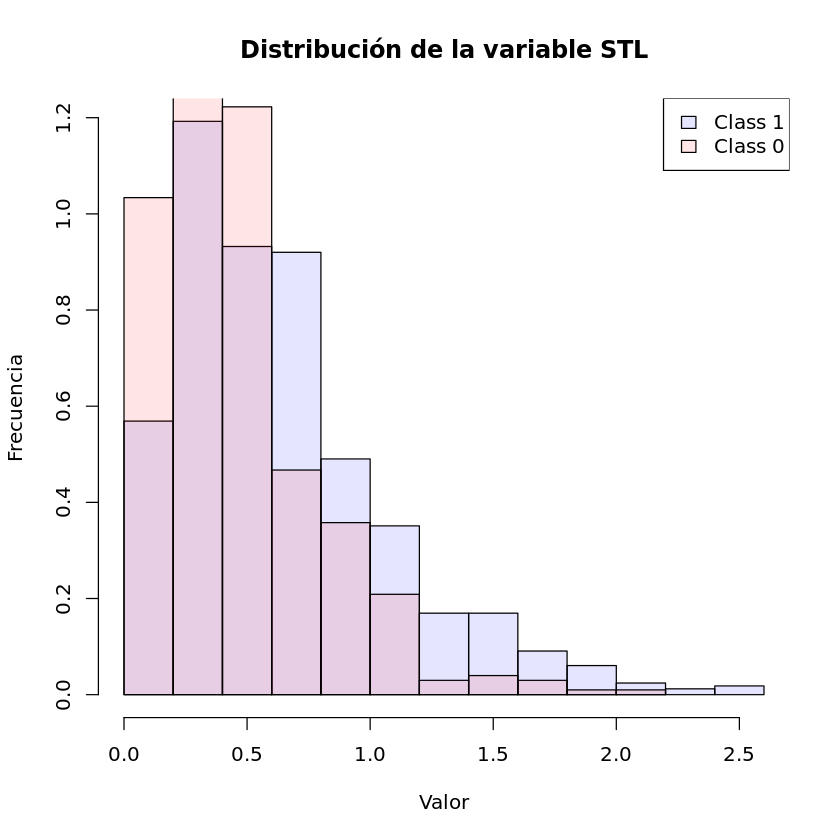

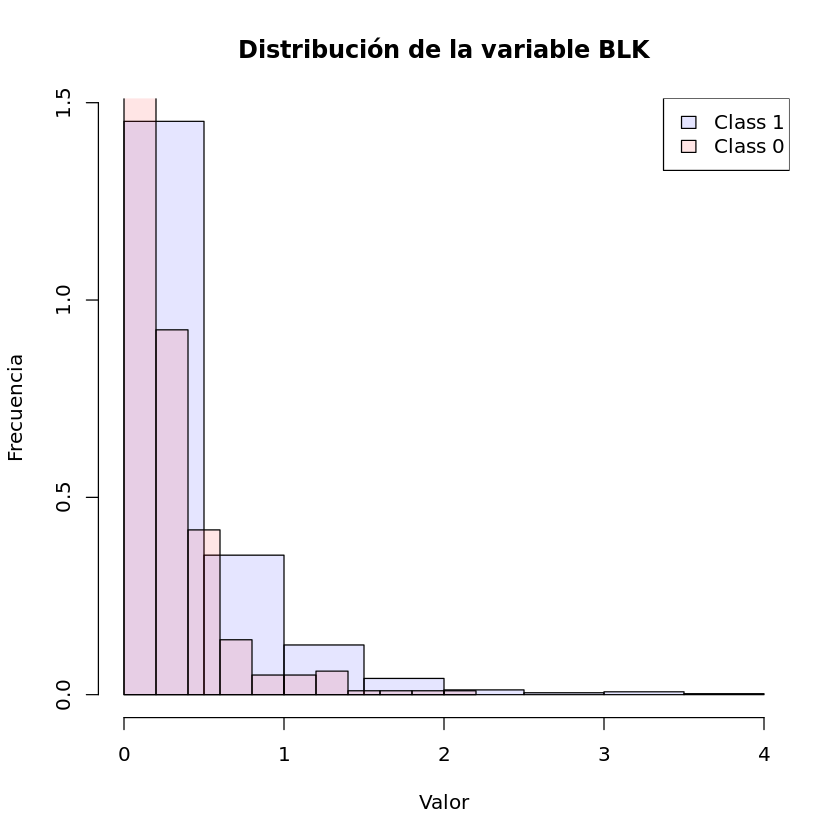

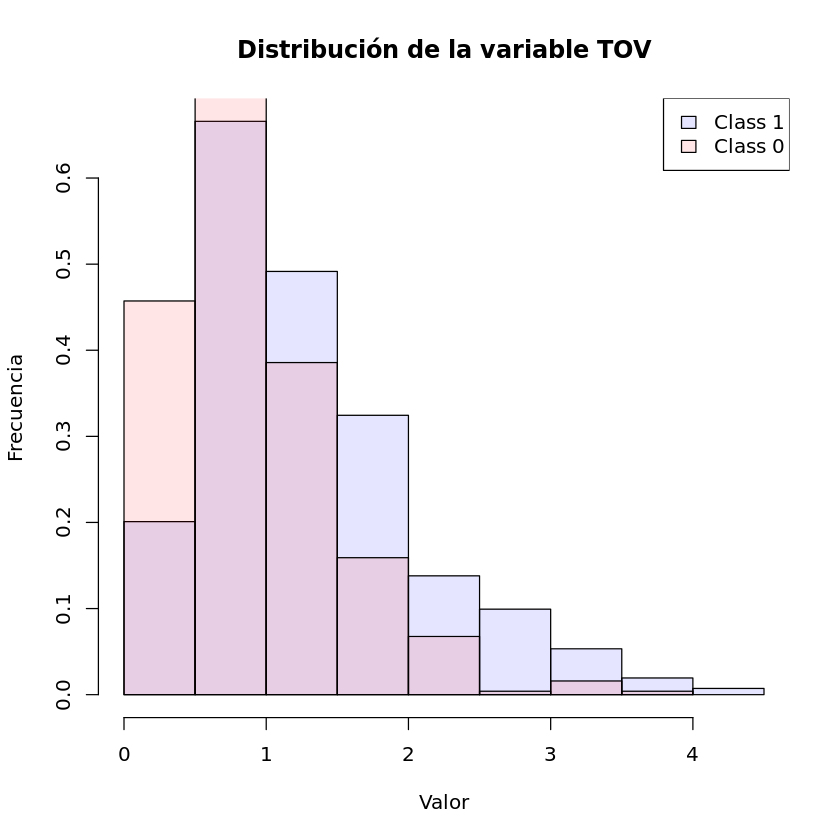

In [10]:
for (i in 2:((length(colnames(nba)))-1))
{
    hist(nba_1[,i], main = paste0("Distribución de la variable ", colnames(nba)[i]), xlab = "Valor", ylab= "Frecuencia", col=rgb(0,0,1,0.1), prob = T)
    hist(nba_0[,i], xlab = "Valor", ylab= "Frecuencia", col=rgb(1,0,0,0.1), prob = T, add = T)
    legend("topright", c("Class 1", "Class 0"), fill=c(rgb(0,0,1,0.1), rgb(1,0,0,0.1)))
}

## 2. Information Gain Algorithms:
Con tal de ver la información mutua entre el target y las covariables se aplican los tres algoritmos detallados a continuación:

- "infogain" : ${H(Class)} + H(Attribute) − H(Class, Attribute)$

- "gainratio" : $H(Class) + H(Attribute) − H(Class, Attribute) / H(Attribute) $

- "symuncert" : $2 * (H(Class) + H(Attribute) − H(Class, Attribute)) / (H(Attribute) + H(Class)) $

In [11]:
### Seleccionamos variables cuantitativas
nba2 <- select(nba, -Name)

In [12]:
### Infogain: variable target con dataset
i = information_gain(formula = TARGET_5Yrs ~ .
                     , data = nba2
                     , type = 'infogain')
i

Warning message in .information_gain.data.frame(x = x, y = y, type = type, equal = equal, :
“Dependent variable is a numeric! It will be converted to factor with simple factor(y). We do not discretize dependent variable in FSelectorRcpp by default! You can choose equal frequency binning discretization by setting equal argument to TRUE.”


attributes,importance
<chr>,<dbl>
GP,0.08145389
MIN,0.05095769
PTS,0.06363074
FGM,0.06712029
FGA,0.05049903
FG.,0.03422340
X3P.Made,0.00000000
X3PA,0.00000000
X3P.,0.00000000


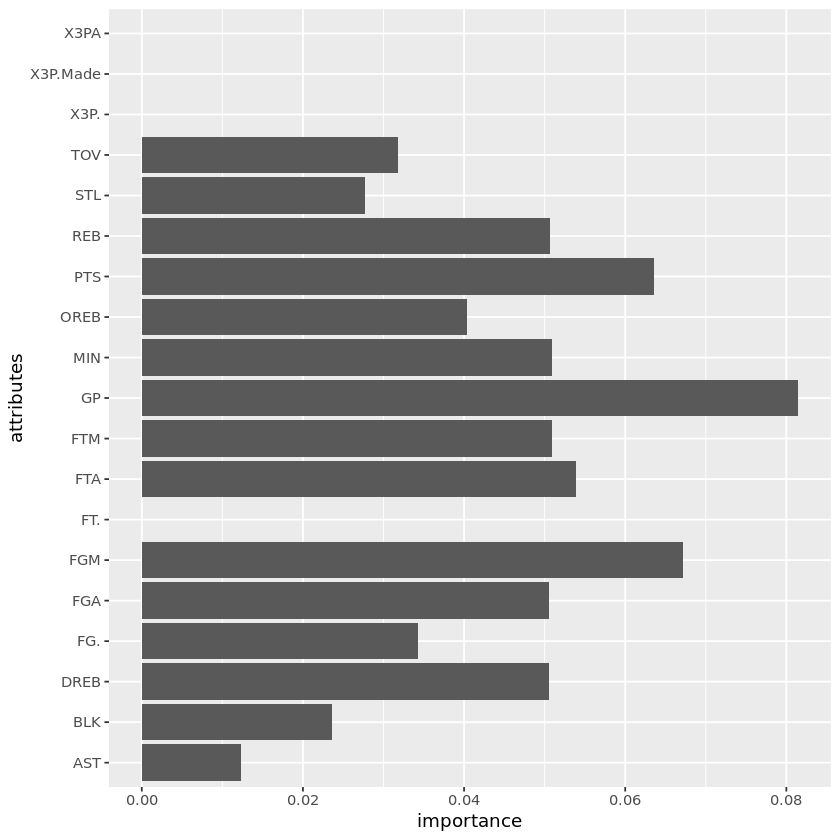

In [13]:
ggplot(i, aes(x=attributes, y=importance)) +
  geom_bar(stat = "identity") +
  coord_flip()

Warning message in .information_gain.data.frame(x = x, y = y, type = type, equal = equal, :
“Dependent variable is a numeric! It will be converted to factor with simple factor(y). We do not discretize dependent variable in FSelectorRcpp by default! You can choose equal frequency binning discretization by setting equal argument to TRUE.”


attributes,importance
<chr>,<dbl>
GP,0.06073664
MIN,0.05185089
PTS,0.05808625
FGM,0.06132776
FGA,0.04630201
FG.,0.06430452
X3P.Made,NaN
X3PA,NaN
X3P.,NaN


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_bar()`).”


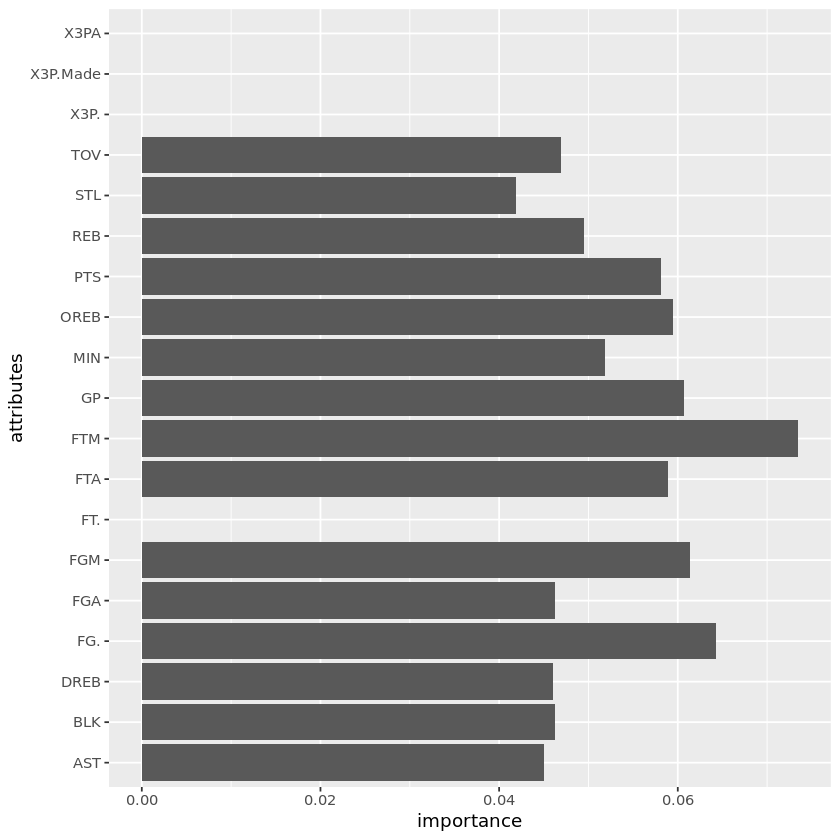

In [14]:
### gainratio: variable target con dataset
i = information_gain(formula = TARGET_5Yrs ~ .
                     , data = nba2
                     , type = 'gainratio')
i
ggplot(i, aes(x=attributes, y=importance)) +
  geom_bar(stat = "identity") +
  coord_flip()

Warning message in .information_gain.data.frame(x = x, y = y, type = type, equal = equal, :
“Dependent variable is a numeric! It will be converted to factor with simple factor(y). We do not discretize dependent variable in FSelectorRcpp by default! You can choose equal frequency binning discretization by setting equal argument to TRUE.”


attributes,importance
<chr>,<dbl>
GP,0.08127448
MIN,0.06191365
PTS,0.07235832
FGM,0.07636994
FGA,0.05758289
FG.,0.05725257
X3P.Made,0.00000000
X3PA,0.00000000
X3P.,0.00000000


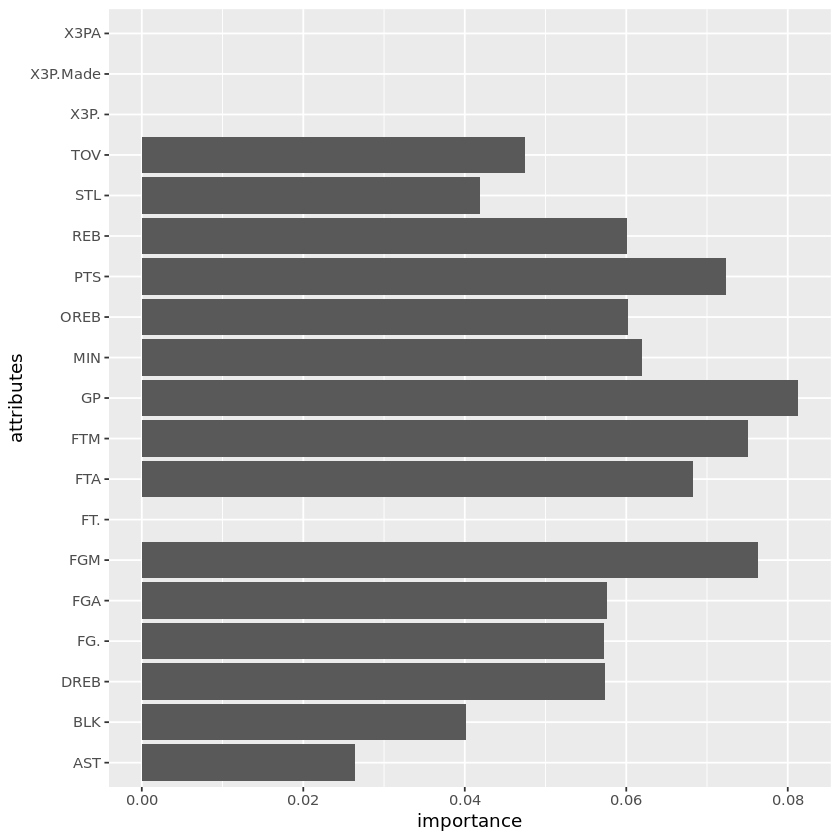

In [15]:
### symuncert: variable target con dataset
i = information_gain(formula = TARGET_5Yrs ~ .
                     , data = nba2
                     , type = 'symuncert')
i
ggplot(i, aes(x=attributes, y=importance)) +
  geom_bar(stat = "identity") +
  coord_flip()

## 3. Análisis de Correlación

A continuación, se realiza un análisis de correlaciones con el objetivo de ver la posible existencia de relaciones lineales entre las covariables y la variable target así como entre las covariables.

In [16]:
cor(nba2)

,GP,MIN,PTS,FGM,FGA,FG.,X3P.Made,X3PA,X3P.,FTM,FTA,FT.,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
GP,1.00000000,0.5905958,0.5390694,0.5430001,0.5173947,0.29698671,0.10819470,0.09962586,0.038209111,0.48318459,0.48013550,0.19774264,0.40018361,0.46746691,0.46039020,0.37431119,0.45272570,0.27669982,0.5186933,0.397782876
MIN,0.59059581,1.0000000,0.9117464,0.9028637,0.9101942,0.20834058,0.38947367,0.40281351,0.165996551,0.79108881,0.77981253,0.23616004,0.57365519,0.74706548,0.71085316,0.62914705,0.75705017,0.40101051,0.8264309,0.316030669
PTS,0.53906940,0.9117464,1.0000000,0.9908739,0.9796763,0.26158711,0.34528932,0.35519760,0.151071831,0.89624544,0.88082551,0.25440359,0.57642075,0.69656013,0.67900156,0.55156085,0.67493681,0.39049580,0.8502722,0.314632051
FGM,0.54300009,0.9028637,0.9908739,1.0000000,0.9801170,0.29711280,0.28795599,0.29789752,0.119493281,0.84814638,0.84066677,0.21942305,0.59746760,0.70519142,0.69267804,0.53226104,0.66245659,0.40074381,0.8343431,0.316393268
FGA,0.51739472,0.9101942,0.9796763,0.9801170,1.0000000,0.13581506,0.38886001,0.41205286,0.197159626,0.82624393,0.80550663,0.26440538,0.50554748,0.64275151,0.61649722,0.58903763,0.68977092,0.32550302,0.8459524,0.290683738
FG.,0.29698671,0.2083406,0.2615871,0.2971128,0.1358151,1.00000000,-0.29157287,-0.34767955,-0.330690063,0.25338059,0.30636017,-0.15099610,0.51234587,0.41110270,0.46612579,-0.10354608,0.06112959,0.39078641,0.1264286,0.235587226
X3P.Made,0.10819470,0.3894737,0.3452893,0.2879560,0.3888600,-0.29157287,1.00000000,0.98257922,0.589855397,0.15571714,0.09305949,0.31225550,-0.21820989,0.01868775,-0.07086521,0.37431435,0.30514630,-0.15595545,0.2570150,0.035024733
X3PA,0.09962586,0.4028135,0.3551976,0.2978975,0.4120529,-0.34767955,0.98257922,1.00000000,0.582336887,0.17046307,0.10578447,0.32090093,-0.23104973,0.01361096,-0.07911139,0.40806650,0.33675720,-0.16924519,0.2824965,0.016150828
X3P.,0.03820911,0.1659966,0.1510718,0.1194933,0.1971596,-0.33069006,0.58985540,0.58233689,1.000000000,0.03031976,-0.03233307,0.32637157,-0.28875949,-0.12294948,-0.19107053,0.26212027,0.19432897,-0.24227385,0.1082770,-0.003410701
FTM,0.48318459,0.7910888,0.8962454,0.8481464,0.8262439,0.25338059,0.15571714,0.17046307,0.030319755,1.00000000,0.98062583,0.25312507,0.58632502,0.65765199,0.65719442,0.47440342,0.59953428,0.41256464,0.8047619,0.295546174


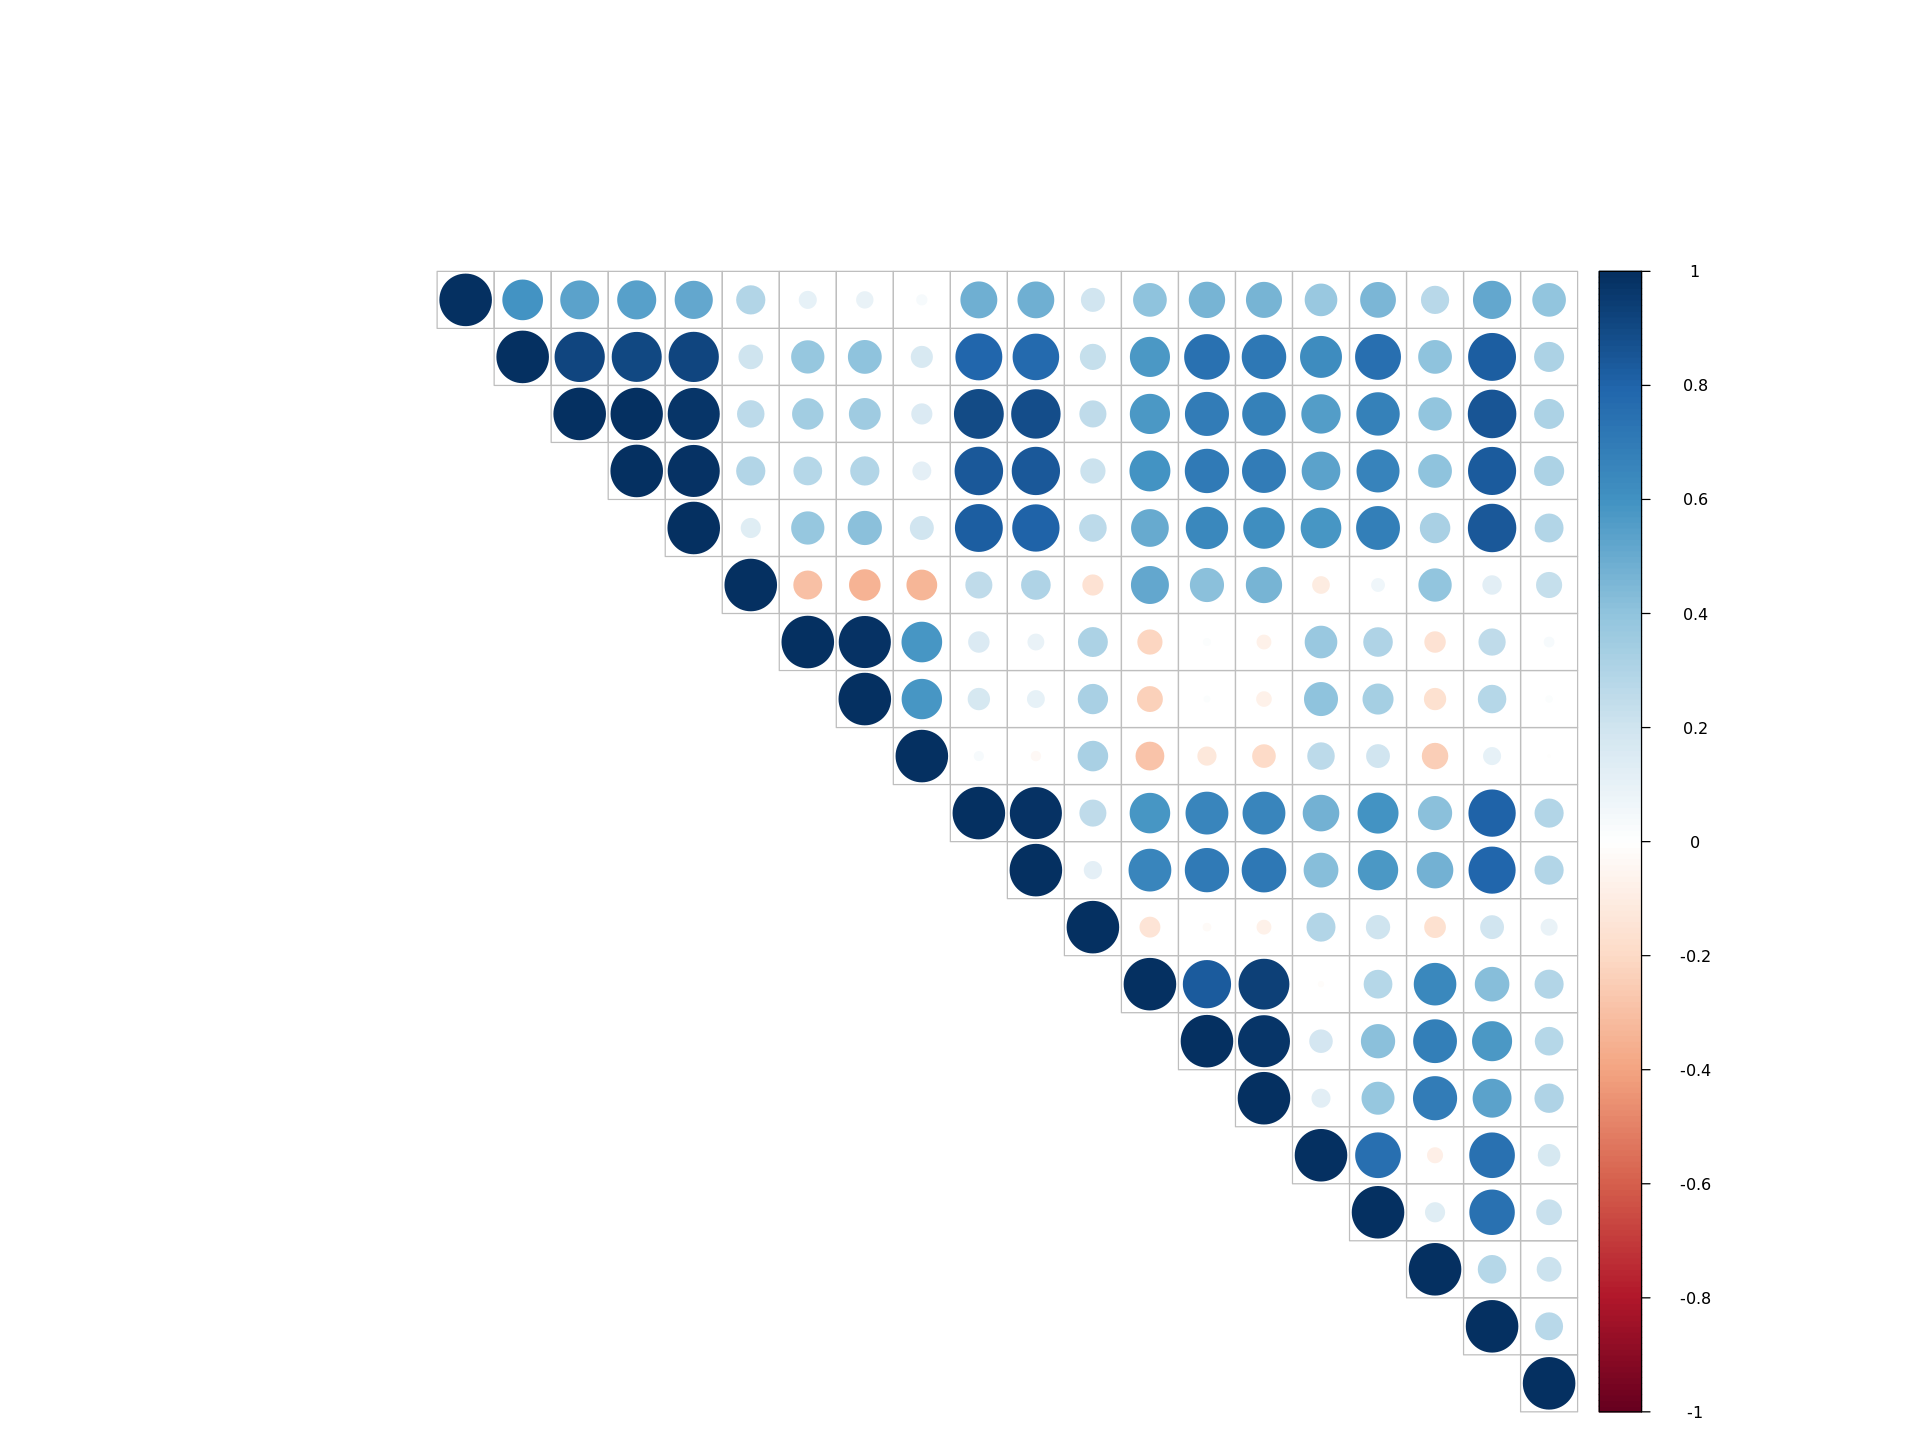

In [23]:
options(repr.plot.width=16, repr.plot.height=12)
### Análisis de correlación
corrplot::corrplot(cor(nba2)
                   , type = "upper"
                   , number.cex = .6
                   , tl.col = "white"
                   , tl.srt = 90)

## 4. Análisis de Componentes Principales

In [24]:
### Duplicamos el objeto nba quitándole el target
nba_no_target <- nba2
nba_no_target$TARGET_5Yrs <- NULL
PCA <- princomp(nba_no_target, scores = T)
summary(PCA)

Importance of components:
                           Comp.1     Comp.2    Comp.3    Comp.4     Comp.5
Standard deviation     19.2025050 16.5676994 9.3667470 7.7050772 5.26922285
Proportion of Variance  0.4457792  0.3318398 0.1060673 0.0717725 0.03356582
Cumulative Proportion   0.4457792  0.7776190 0.8836864 0.9554589 0.98902469
                            Comp.6      Comp.7      Comp.8       Comp.9
Standard deviation     2.011196397 1.639650627 0.975523515 0.7454020494
Proportion of Variance 0.004890047 0.003250175 0.001150481 0.0006717153
Cumulative Proportion  0.993914733 0.997164908 0.998315389 0.9989871042
                            Comp.10      Comp.11      Comp.12      Comp.13
Standard deviation     0.6807755037 0.3402940683 2.790508e-01 2.598324e-01
Proportion of Variance 0.0005602888 0.0001399951 9.413922e-05 8.161886e-05
Cumulative Proportion  0.9995473929 0.9996873880 9.997815e-01 9.998631e-01
                            Comp.14      Comp.15      Comp.16      Comp.17
Standar

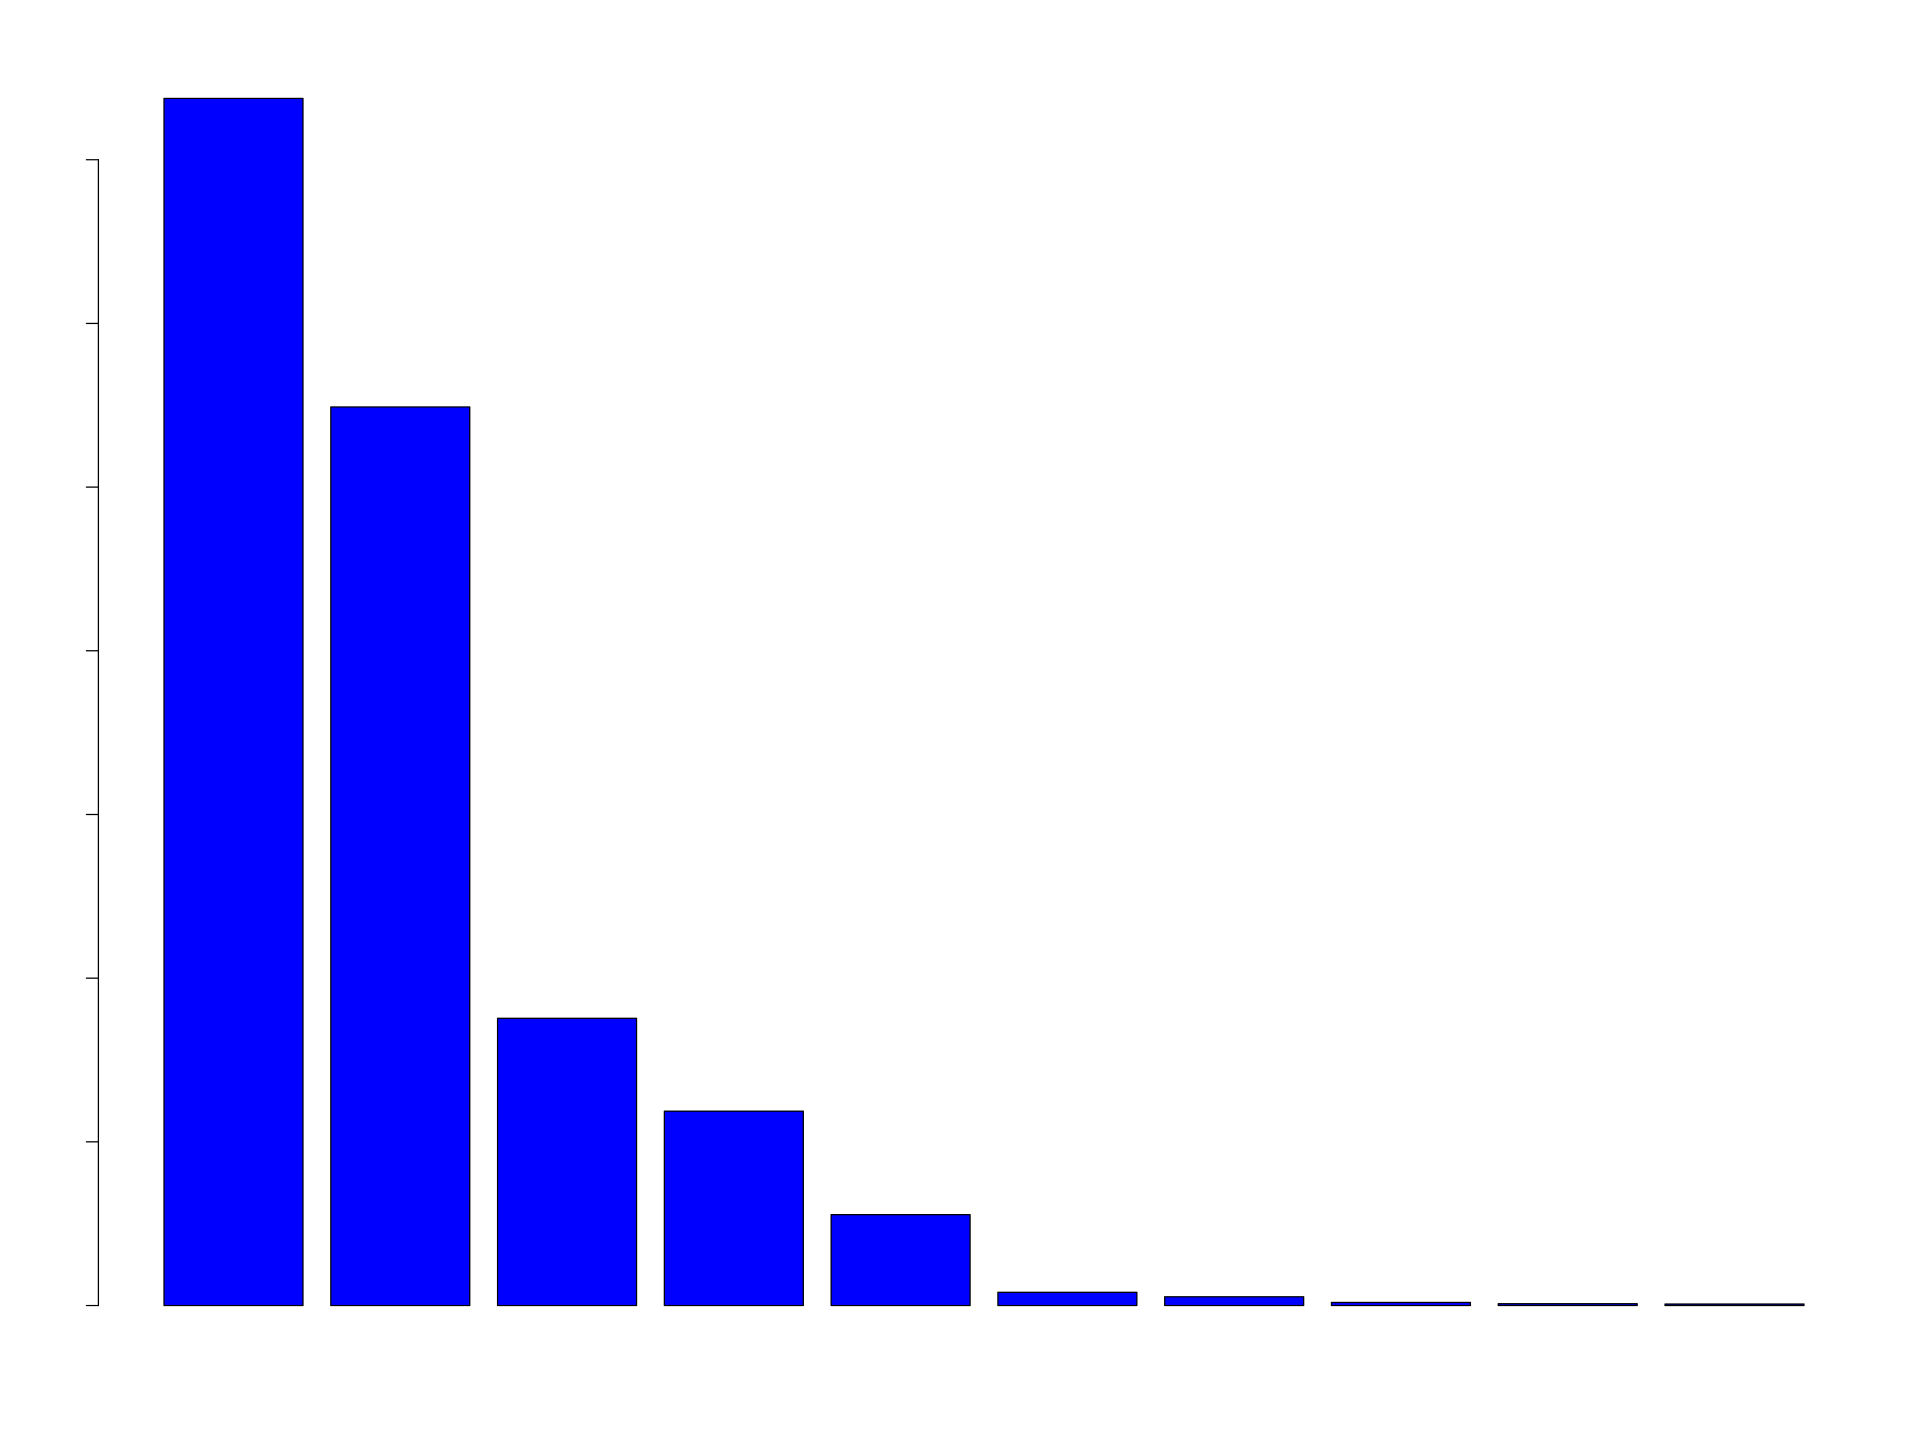

In [37]:
par(col.axis="white", col.lab="white", col.main="white")
plot(PCA, type="bar", col="blue")

In [26]:
PCA$loadings


Loadings:
         Comp.1 Comp.2 Comp.3 Comp.4 Comp.5 Comp.6 Comp.7 Comp.8 Comp.9 Comp.10
GP        0.854  0.304  0.150  0.388                                           
MIN       0.319               -0.705  0.163 -0.550 -0.128         0.109 -0.184 
PTS       0.157               -0.378         0.584                0.143  0.111 
FGM                           -0.146         0.229               -0.186        
FGA       0.127               -0.307         0.471         0.229 -0.400        
FG.              0.177        -0.144 -0.958        -0.129                      
X3P.Made                                                   0.165  0.103  0.267 
X3PA                                               -0.161  0.440  0.268  0.730 
X3P.      0.257 -0.901  0.315        -0.139                                    
FTM                                          0.136        -0.278  0.416        
FTA                           -0.104         0.179  0.112 -0.388  0.551        
FT.       0.211 -0.242 -0.933

## 5.ANOVA

In [27]:
for (i in 1:((length(colnames(nba2)))-1))
{
    anova <- aov(nba2[,i] ~ TARGET_5Yrs, data = nba2)
    print(paste0("ANOVA para la variable: ", colnames(nba2)[i]))
    print(summary(anova))
}

[1] "ANOVA para la variable: GP"
              Df Sum Sq Mean Sq F value Pr(>F)    
TARGET_5Yrs    1  64214   64214   249.4 <2e-16 ***
Residuals   1327 341608     257                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "ANOVA para la variable: MIN"
              Df Sum Sq Mean Sq F value Pr(>F)    
TARGET_5Yrs    1   9198    9198   147.2 <2e-16 ***
Residuals   1327  82894      62                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "ANOVA para la variable: PTS"
              Df Sum Sq Mean Sq F value Pr(>F)    
TARGET_5Yrs    1   2506  2505.6   145.8 <2e-16 ***
Residuals   1327  22805    17.2                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "ANOVA para la variable: FGM"
              Df Sum Sq Mean Sq F value Pr(>F)    
TARGET_5Yrs    1    378   378.3   147.6 <2e-16 ***
Residuals   1327   3401     2.6                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05

## 6.Regresión logística
Después de haber realizado un análisis de **correlaciones** para ver las posibles relaciones lineales entre variables se ha descartado una relación lineal entre la variable target y las covariables. No obstante, se han visto algunas correlaciones altas -inclusive alguna prácticamente perfecta- entre las covariables. Las variables más destacadas del estudio de correlación han sido: **GP, FGM y MIN**.

En el **análisis de componentes principales** se han tenido en cuenta los primeros cuatro PC explicando el 95.53% de la varianza. Aparte de la variable GP y MIN se ha destacado la importancia de las variables **PTS, FGA, FT., FG.** y X3P.. No obstante, mediante los diversos algoritmos aplicados para la información mútua de las variables con la variable target, se ha descartado la variable X3P. ya que no contenía información mutua en ninguno de los casos. Mediante el primer algoritmo se ha visto -como ya se había visto en los análisis anteriores- la importancia de GP, PTS y FGM y se ha visto la relevancia de las variables **REB y FTA**. En el segundo algoritmo se observa la importancia de las variables FTM, FG., GP, FGM y PTS y finalmente en el último algoritmo los resultados han sido muy parecidos al primero. Así pues, destacaríamos la importancia de estas 9 variables para realizar el modelo. Teniendo en cuenta los tres algoritmos y los análisis de correlaciones y de componentes principales previos se eligen como variables para configurar un primer modelo: **GP, PTS, FGM, REB, FTA, FTM y FG.**.

Así pues, a continuación se realiza un primer modelo con las variables elegidas.

In [28]:
str(nba2)

'data.frame':	1329 obs. of  20 variables:
 $ GP         : int  36 35 74 58 48 75 62 48 65 42 ...
 $ MIN        : num  27.4 26.9 15.3 11.6 11.5 11.4 10.9 10.3 9.9 8.5 ...
 $ PTS        : num  7.4 7.2 5.2 5.7 4.5 3.7 6.6 5.7 2.4 3.7 ...
 $ FGM        : num  2.6 2 2 2.3 1.6 1.5 2.5 2.3 1 1.4 ...
 $ FGA        : num  7.6 6.7 4.7 5.5 3 3.5 5.8 5.4 2.4 3.5 ...
 $ FG.        : num  34.7 29.6 42.2 42.6 52.4 42.3 43.5 41.5 39.2 38.3 ...
 $ X3P.Made   : num  0.5 0.7 0.4 0.1 0 0.3 0 0.4 0.1 0.1 ...
 $ X3PA       : num  2.1 2.8 1.7 0.5 0.1 1.1 0.1 1.5 0.5 0.3 ...
 $ X3P.       : num  25 23.5 24.4 22.6 0 32.5 50 30 23.3 21.4 ...
 $ FTM        : num  1.6 2.6 0.9 0.9 1.3 0.4 1.5 0.7 0.4 1 ...
 $ FTA        : num  2.3 3.4 1.3 1.3 1.9 0.5 1.8 0.8 0.5 1.4 ...
 $ FT.        : num  69.9 76.5 67 68.9 67.4 73.2 81.1 87.5 71.4 67.8 ...
 $ OREB       : num  0.7 0.5 0.5 1 1 0.2 0.5 0.8 0.2 0.4 ...
 $ DREB       : num  3.4 2 1.7 0.9 1.5 0.7 1.4 0.9 0.6 0.7 ...
 $ REB        : num  4.1 2.4 2.2 1.9 2.5 0.8 2 1.7 

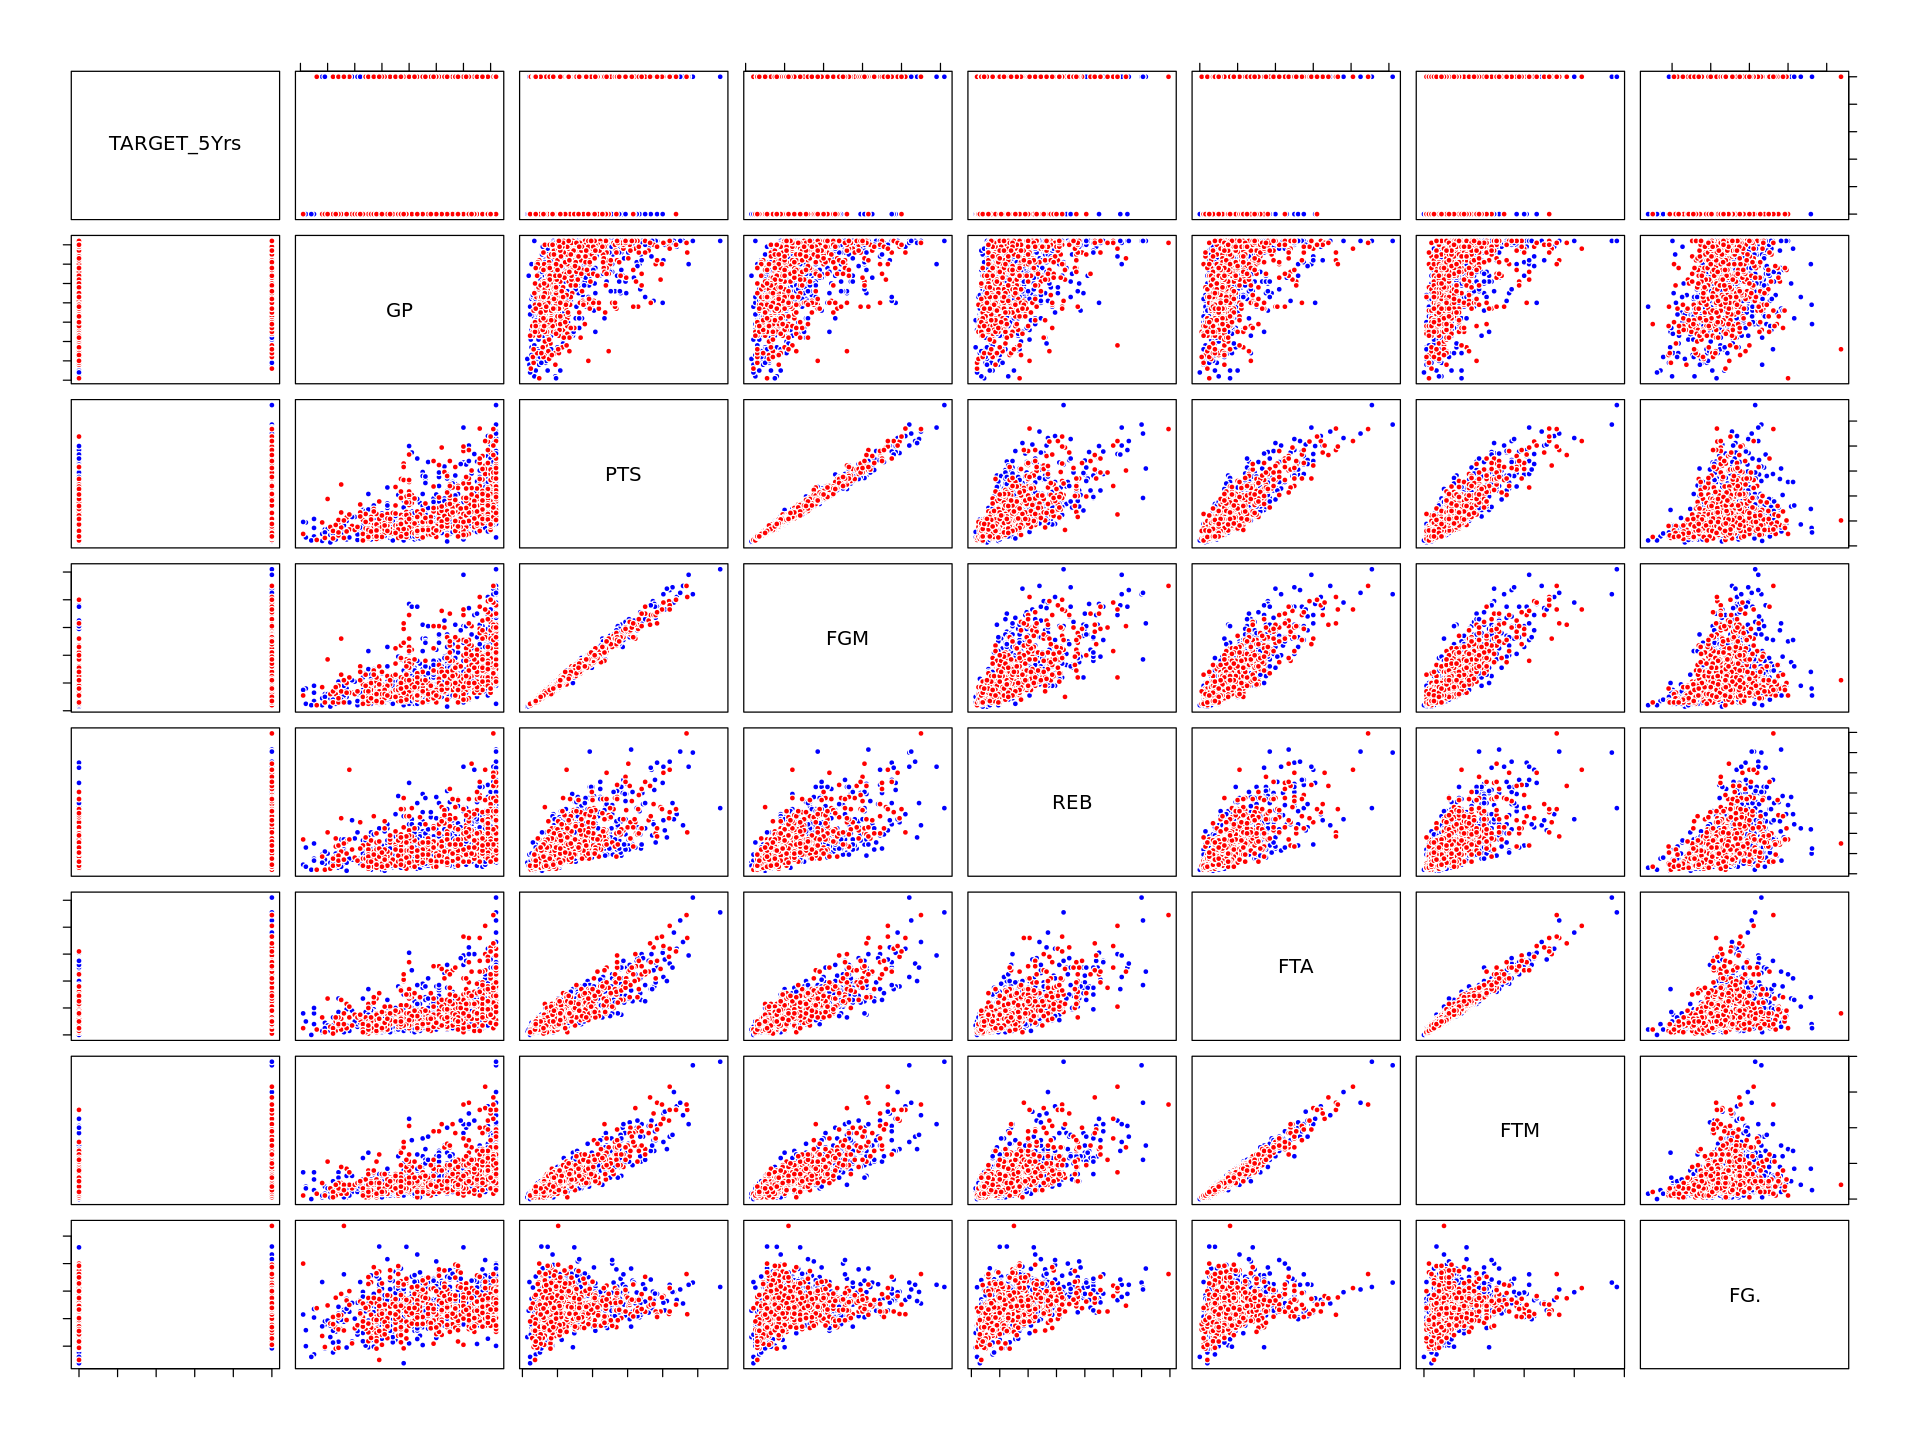

In [39]:
nba_subset <- subset(nba, select = c(TARGET_5Yrs, GP, PTS, FGM, REB, FTA, FTM, FG.))

# Le asignamos el color verde a las no fumadoras y el rojo a las fumadoras
nba_1_s <- sum(nba_subset$TARGET_5Yrs == 1)
nba_0_s <- sum(nba_subset$TARGET_5Yrs == 0)
colores <- c(rep('blue',nba_1_s), rep('red',nba_0_s))

#Graficamos la dispersion por pares para tener una primera aproximacion de la relacion de las variables
# options(repr.plot.width=14, repr.plot.height=14)
par(col.axis="white", col.lab="white", col.main="white", cex.axis=1.2, cex.lab=1.2)
pairs(nba_subset, pch = 21, bg = colores, cex.labels=1.5, col="white")

In [40]:
### Generamos un primer modelo unicamente con la variable GP
m0 <- glm(formula = TARGET_5Yrs ~ GP
          , data = nba2
          , family = "binomial")
summary(m0)


Call:
glm(formula = TARGET_5Yrs ~ GP, family = "binomial", data = nba2)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.9199  -1.0444   0.6152   0.8606   1.9328  

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.517244   0.226566  -11.11   <2e-16 ***
GP           0.051072   0.003758   13.59   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1763.1  on 1328  degrees of freedom
Residual deviance: 1545.7  on 1327  degrees of freedom
AIC: 1549.7

Number of Fisher Scoring iterations: 4


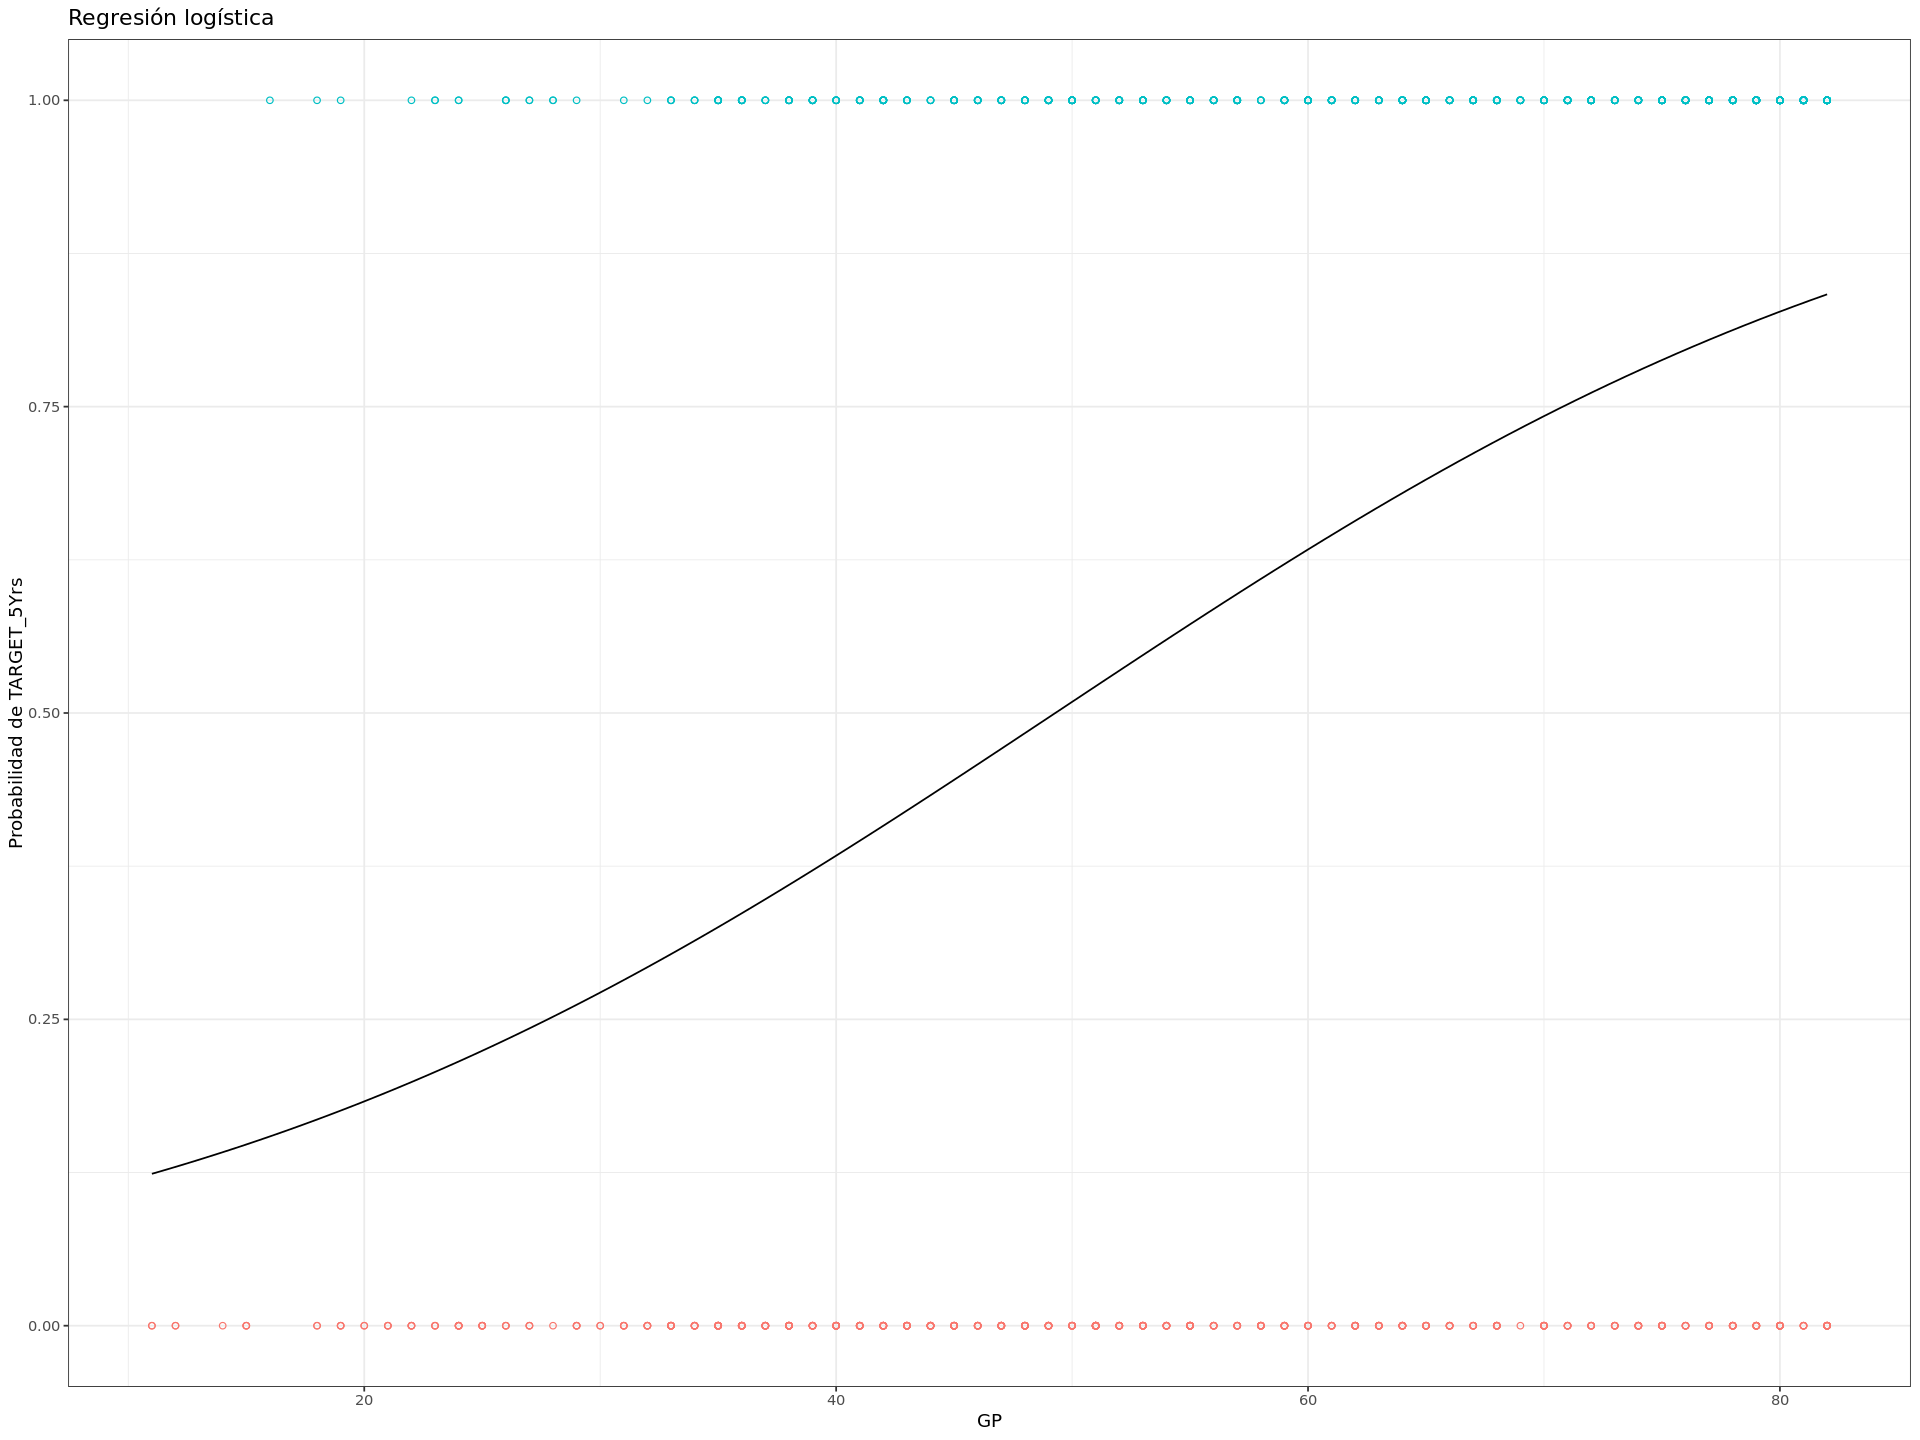

In [41]:
# Representación gráfica del modelo.
ggplot(data = nba, aes(x = GP, y = TARGET_5Yrs)) +
  geom_point(aes(color = as.factor(TARGET_5Yrs)), shape = 1) +
  stat_function(fun = function(x){predict(m0,
                                          newdata = data.frame(GP = x),
                                          type = "response")}) +
  theme_bw() +
  labs(title = "Regresión logística",
       y = "Probabilidad de TARGET_5Yrs") +
  theme(legend.position = "none")

In [32]:
### Generamos un primer modelo con las variables consideradas importantes por los diferentes análisis
m1 <- glm(formula = TARGET_5Yrs ~ GP + PTS + FGM + REB + FTA + FTM + FG.
          , data = nba2
          , family = "binomial")
summary(m1)


Call:
glm(formula = TARGET_5Yrs ~ GP + PTS + FGM + REB + FTA + FTM + 
    FG., family = "binomial", data = nba2)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.7024  -0.9968   0.5559   0.8545   1.9678  

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.839203   0.538218  -7.133 9.81e-13 ***
GP           0.035583   0.004401   8.084 6.25e-16 ***
PTS         -0.016777   0.206274  -0.081  0.93517    
FGM          0.075171   0.461240   0.163  0.87054    
REB          0.128867   0.058679   2.196  0.02808 *  
FTA         -0.407329   0.318794  -1.278  0.20135    
FTM          0.775011   0.493971   1.569  0.11666    
FG.          0.035639   0.012318   2.893  0.00381 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1763.1  on 1328  degrees of freedom
Residual deviance: 1492.8  on 1321  degrees of freedom
AIC: 1508.8

Number of Fisher Scori

In [42]:
### Vemos la predicción para cada instancia
m1_prob <- predict(m1, type = 'response')
m1_pred <- ifelse(m1_prob > 0.5, 1, 0)

### Generamos matriz de confusión
c <- confusionMatrix(as.factor(m1_pred), as.factor(nba2$TARGET_5Yrs))
c

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 267 152
         1 236 674
                                          
               Accuracy : 0.7081          
                 95% CI : (0.6828, 0.7324)
    No Information Rate : 0.6215          
    P-Value [Acc > NIR] : 2.172e-11       
                                          
                  Kappa : 0.3585          
                                          
 Mcnemar's Test P-Value : 2.512e-05       
                                          
            Sensitivity : 0.5308          
            Specificity : 0.8160          
         Pos Pred Value : 0.6372          
         Neg Pred Value : 0.7407          
             Prevalence : 0.3785          
         Detection Rate : 0.2009          
   Detection Prevalence : 0.3153          
      Balanced Accuracy : 0.6734          
                                          
       'Positive' Class : 0               
                              

Se puede ver como las variables PTS, FGM y FTA y FTM no resultan significativas (por su p-value superior a 0.05) y se decide realizar un segundo modelo excluyéndolas.

In [33]:
### Generamos un primer modelo con las variables consideradas importantes por los diferentes análisis
m2 <- glm(formula = TARGET_5Yrs ~ GP + REB + FG.
          , data = nba2
          , family = binomial)
summary(m2)


Call:
glm(formula = TARGET_5Yrs ~ GP + REB + FG., family = binomial, 
    data = nba2)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.5362  -1.0097   0.5769   0.8567   1.9235  

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.741711   0.505735  -7.399 1.38e-13 ***
GP           0.040243   0.004099   9.818  < 2e-16 ***
REB          0.186017   0.044185   4.210 2.55e-05 ***
FG.          0.030700   0.011534   2.662  0.00777 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1763.1  on 1328  degrees of freedom
Residual deviance: 1503.5  on 1325  degrees of freedom
AIC: 1511.5

Number of Fisher Scoring iterations: 4


In [34]:
### Generamos las predicciones de nuestro modelo
m2_prob <- predict(m2, type = 'response')
head(m2_prob)

1         2         3         4         5         6 
0.3858001 0.2732806 0.7193146 0.5630733 0.5655399 0.6734771

In [35]:
### Vemos la predicción para cada instancia
m2_pred <- ifelse(m2_prob > 0.5, 1, 0)
head(m2_pred)

sum(m2_pred == 1)

1 2 3 4 5 6 
0 0 1 1 1 1

[1] 928

In [36]:
### Generamos matriz de confusión
c <- confusionMatrix(as.factor(m2_pred), as.factor(nba2$TARGET_5Yrs))
c

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 256 145
         1 247 681
                                          
               Accuracy : 0.705           
                 95% CI : (0.6797, 0.7295)
    No Information Rate : 0.6215          
    P-Value [Acc > NIR] : 1.031e-10       
                                          
                  Kappa : 0.3472          
                                          
 Mcnemar's Test P-Value : 3.374e-07       
                                          
            Sensitivity : 0.5089          
            Specificity : 0.8245          
         Pos Pred Value : 0.6384          
         Neg Pred Value : 0.7338          
             Prevalence : 0.3785          
         Detection Rate : 0.1926          
   Detection Prevalence : 0.3017          
      Balanced Accuracy : 0.6667          
                                          
       'Positive' Class : 0               
                              

## 6. Conclusiones

...